<a href="https://colab.research.google.com/github/Claudio-Ferriz/Proyecto-AP-PS/blob/main/Proyecto_AP_PS_Mejorado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Aprobación Presidencial y Protesta Social
## Análisis comparativo por países, series de tiempo y correlación

Este notebook realiza un análisis integral que incluye:
1. **Carga y limpieza de datos**
2. **Análisis exploratorio (EDA)** por país
3. **Análisis comparativo entre países**
4. **Series de tiempo** de aprobación presidencial y protesta social
5. **Análisis de correlación** entre ambas variables
6. **Análisis de outliers y eventos críticos**

---
## 0. Configuración e Importación de Librerías

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Estilo global de visualizaciones
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')
PALETTE = 'tab10'

print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


---
## 1. Carga y Limpieza de Datos

In [ ]:
# --- Aprobación Presidencial ---
df_ap = pd.read_excel(
    'https://github.com/Claudio-Ferriz/Proyecto-AP-PS/raw/refs/heads/main/'
    'Copia%20de%20Encuestas%20Aprobaci%C3%B3n%20Presidencial%202025%20-%20Solo%20Base%20Integrada.xlsx'
)

# Eliminar columnas 'Unnamed'
df_ap = df_ap.drop(columns=[c for c in df_ap.columns if c.startswith('Unnamed')])

# Convertir Año a entero
df_ap['Año'] = df_ap['Año'].astype('Int64')

print(f'📊 Aprobación Presidencial: {df_ap.shape[0]:,} registros | {df_ap.shape[1]} columnas')
df_ap.head(3)

📊 Aprobación Presidencial: 2,869 registros | 21 columnas


,País,Región I,Región II,Tipo de Encuesta,Consultora,Mes,Año,Fecha,Aprueba,Presidente,...,Tipo de Presidente,Fecha asunción,Días de presidencia,Presidencial / Parlamentario,Unitario o Federal,Población,Indice Desarrollo Humano,PBI per capita (PPA),Tasa Desempleo,Inflación
0,Alemania,Europa,Europa,Online,Televisión pública ARD,Abril,2020,2020-04-03,64.0,Angela Merkel,...,Insider,2005-11-22,5246.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.4
1,Alemania,Europa,Europa,Online,Civey,Mayo,2020,2020-05-06,61.0,Angela Merkel,...,Insider,2005-11-22,5279.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5
2,Alemania,Europa,Europa,Online,Civey,Mayo,2020,2020-05-21,64.0,Angela Merkel,...,Insider,2005-11-22,5294.0,Parlamentario,Federal,83160343.0,0.944,57905,5.9,0.5


In [ ]:
# --- Protesta Social ---
df_ps = pd.read_excel(
    'https://github.com/Claudio-Ferriz/Proyecto-AP-PS/raw/refs/heads/main/'
    'Copia%20de%20Protesta_Social_Aggregated_Data_Up_To-2026-02-28.xlsx'
)

# Agregar por Mes, Año y País
df_ps = df_ps.groupby(['Mes', 'Año', 'País'])['Cantidad de Eventos de Protesta'].sum().reset_index()

print(f'📊 Protesta Social: {df_ps.shape[0]:,} registros | {df_ps.shape[1]} columnas')
df_ps.head(3)

📊 Protesta Social: 1,574 registros | 4 columnas


,Mes,Año,País,Cantidad de Eventos de Protesta
0,Abril,2018,Argentina,230
1,Abril,2018,Bolivia,21
2,Abril,2018,Brasil,1379


In [ ]:
# --- Merge: AP + PS ---
df_ap_ps = pd.merge(df_ap, df_ps, on=['Mes', 'Año', 'País'], how='inner')

# Crear variables agregadas a nivel mes-año-país
df_ap_ps['Aprueba_Mes'] = df_ap_ps.groupby(['Mes', 'Año', 'País'])['Aprueba'].transform('mean')
df_ap_ps['Protestas_Mes'] = df_ap_ps.groupby(['Mes', 'Año', 'País'])['Cantidad de Eventos de Protesta'].transform('first')

# DataFrame consolidado (un registro por Mes-Año-País)
df = df_ap_ps.groupby(['Mes', 'Año', 'País'], as_index=False).agg(
    Protestas=('Cantidad de Eventos de Protesta', 'first'),
    Aprobacion=('Aprueba', 'mean')
)

# Diccionario de meses en español → número
MESES = {
    'Enero': 1, 'Febrero': 2, 'Marzo': 3, 'Abril': 4,
    'Mayo': 5, 'Junio': 6, 'Julio': 7, 'Agosto': 8,
    'Septiembre': 9, 'Octubre': 10, 'Noviembre': 11, 'Diciembre': 12
}
df['Mes_num'] = df['Mes'].map(MESES)
df['Fecha'] = pd.to_datetime(
    df['Año'].astype(str) + '-' + df['Mes_num'].astype(str) + '-01',
    errors='coerce'
)
df = df.sort_values(['País', 'Fecha']).reset_index(drop=True)

PAISES = sorted(df['País'].unique())
print(f'✅ Dataset consolidado: {df.shape[0]:,} registros | {len(PAISES)} países')
print(f'   Países: {PAISES}')
df.head(5)

✅ Dataset consolidado: 1,077 registros | 18 países
   Países: ['Alemania', 'Argentina', 'Bolivia', 'Brasil', 'Canadá', 'Chile', 'Colombia', 'Ecuador', 'España', 'Estados Unidos', 'Francia', 'Inglaterra', 'Italia', 'México', 'Paraguay', 'Perú', 'Portugal', 'Uruguay']


,Mes,Año,País,Protestas,Aprobacion,Mes_num,Fecha
0,Abril,2020,Alemania,313,64.000000,4,2020-04-01
1,Mayo,2020,Alemania,612,64.333333,5,2020-05-01
2,Junio,2020,Alemania,419,53.500000,6,2020-06-01
3,Julio,2020,Alemania,306,67.000000,7,2020-07-01
4,Agosto,2020,Alemania,343,65.000000,8,2020-08-01


In [ ]:
df.drop(df[df['País'].isin(['Bolivia', 'Paraguay', 'Portugal'])].index, inplace=True)

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df['País'].unique()

array(['Alemania', 'Argentina', 'Brasil', 'Canadá', 'Chile', 'Colombia',
       'Ecuador', 'España', 'Estados Unidos', 'Francia', 'Inglaterra',
       'Italia', 'México', 'Perú', 'Uruguay'], dtype=object)

In [ ]:
poblacion = {
    "Argentina": 45696159,
    "Brasil": 211998573,
    "Canadá": 41288599,
    "Chile": 19764771,
    "Colombia": 52886363,
    "Alemania": 83516593,
    "Ecuador": 18135478,
    "España": 48848840,
    "Francia": 68551653,
    "Inglaterra": 69226000,
    "Italia": 58952704,
    "México": 130861007,
    "Perú": 34217848,
    "Uruguay": 3386588,
    "Estados Unidos": 340110988,
}

# Columna de población total por país (sin eliminar ninguna columna existente)
df["Población_total"] = df["País"].map(poblacion)

# Tasa de protestas: protestas por cada 100.000 habitantes
df["Tasa_Protestas"] = (df["Protestas"] / df["Población_total"]) * 100000

# Chequeo de países que no matchearon (por si algún nombre no coincide)
sin_poblacion = df[df["Población_total"].isna()]["País"].unique()
print("Países sin match de población:", sin_poblacion)



Países sin match de población: []


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1003 entries, 0 to 1002
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Mes              1003 non-null   object        
 1   Año              1003 non-null   Int64         
 2   País             1003 non-null   object        
 3   Protestas        1003 non-null   int64         
 4   Aprobacion       1003 non-null   float64       
 5   Mes_num          1003 non-null   int64         
 6   Fecha            1003 non-null   datetime64[ns]
 7   Población_total  1003 non-null   int64         
 8   Tasa_Protestas   1003 non-null   float64       
dtypes: Int64(1), datetime64[ns](1), float64(2), int64(3), object(2)
memory usage: 71.6+ KB


In [ ]:
# --- Resumen de calidad de datos ---
print('=== Valores nulos por columna ===')
print(df.isnull().sum())
print()
print('=== Estadísticas descriptivas ===')
df[['Aprobacion', 'Protestas']].describe().round(2)

=== Valores nulos por columna ===
Mes                0
Año                0
País               0
Protestas          0
Aprobacion         0
Mes_num            0
Fecha              0
Población_total    0
Tasa_Protestas     0
dtype: int64

=== Estadísticas descriptivas ===


,Aprobacion,Protestas
count,1003.00,1003.00
mean,39.13,460.87
std,15.31,492.57
min,2.50,1.00
25%,29.33,130.50
50%,38.00,271.00
75%,49.00,705.50
max,85.00,4736.00


---
## 2. Análisis Exploratorio (EDA) por País
### 2.1 Distribuciones de Aprobación Presidencial y Protesta Social

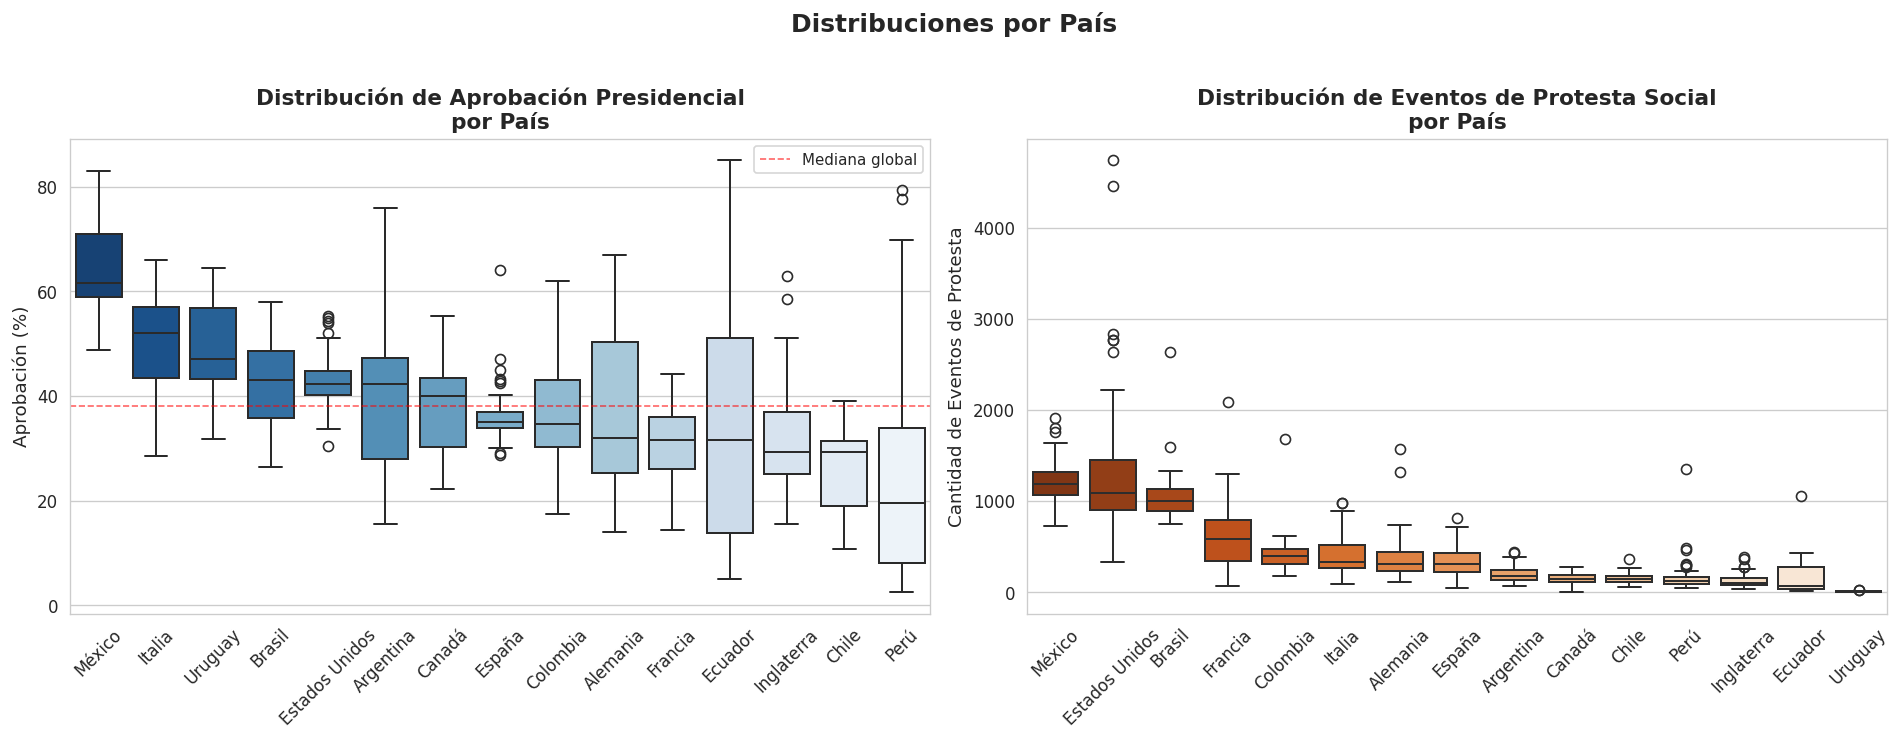

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Aprobación presidencial por país
ax = axes[0]
order_ap = df.groupby('País')['Aprobacion'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='País', y='Aprobacion', order=order_ap,
            palette='Blues_r', ax=ax, linewidth=1.2)
ax.set_title('Distribución de Aprobación Presidencial\npor País', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Aprobación (%)', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.axhline(df['Aprobacion'].median(), color='red', linestyle='--', linewidth=1, alpha=0.6, label='Mediana global')
ax.legend(fontsize=9)

# Protesta social por país
ax = axes[1]
order_ps = df.groupby('País')['Protestas'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='País', y='Protestas', order=order_ps,
            palette='Oranges_r', ax=ax, linewidth=1.2)
ax.set_title('Distribución de Eventos de Protesta Social\npor País', fontsize=13, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Cantidad de Eventos de Protesta', fontsize=11)
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribuciones por País', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

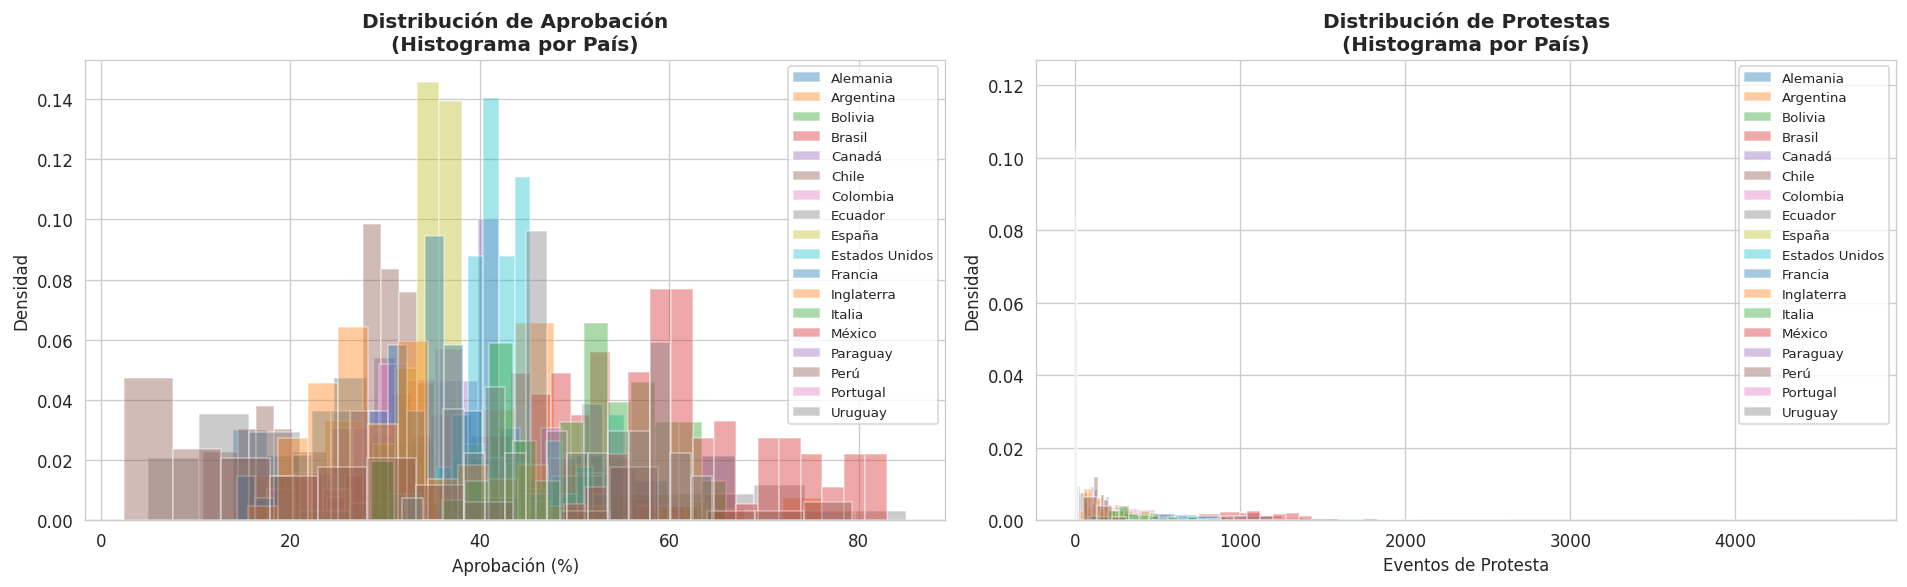

In [ ]:
# Histogramas con curva KDE
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for pais in PAISES:
    sub = df[df['País'] == pais]
    axes[0].hist(sub['Aprobacion'].dropna(), bins=15, alpha=0.4, label=pais, density=True)
    axes[1].hist(sub['Protestas'].dropna(), bins=15, alpha=0.4, label=pais, density=True)

axes[0].set_title('Distribución de Aprobación\n(Histograma por País)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Aprobación (%)')
axes[0].set_ylabel('Densidad')
axes[0].legend(fontsize=8)

axes[1].set_title('Distribución de Protestas\n(Histograma por País)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Eventos de Protesta')
axes[1].set_ylabel('Densidad')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 2.2 Estadísticas Resumidas por País

In [ ]:
resumen = df.groupby('País').agg(
    Meses_con_datos=('Fecha', 'count'),
    AP_media=('Aprobacion', 'mean'),
    AP_mediana=('Aprobacion', 'median'),
    AP_std=('Aprobacion', 'std'),
    AP_min=('Aprobacion', 'min'),
    AP_max=('Aprobacion', 'max'),
    PS_media=('Protestas', 'mean'),
    PS_mediana=('Protestas', 'median'),
    PS_total=('Protestas', 'sum'),
    PS_max=('Protestas', 'max')
).round(2)

resumen = resumen.sort_values('AP_media', ascending=False)
print('=== Estadísticas por País ===')
resumen

=== Estadísticas por País ===


,Meses_con_datos,AP_media,AP_mediana,AP_std,AP_min,AP_max,PS_media,PS_mediana,PS_total,PS_max
País,,,,,,,,,,
México,80,64.67,61.63,8.31,48.86,83.00,1199.82,1182.5,95986,1908
Italia,61,50.41,52.00,8.87,28.50,66.00,410.70,329.0,25053,982
Uruguay,62,49.04,47.00,8.02,31.80,64.50,6.58,6.0,408,27
Estados Unidos,69,42.97,42.30,4.69,30.50,55.25,1315.36,1091.0,90760,4736
Brasil,68,42.05,43.00,7.87,26.50,58.00,1039.35,1006.0,70676,2638
Argentina,68,39.43,42.26,13.03,15.57,76.00,198.59,182.0,13504,437
Canadá,59,38.62,40.00,8.51,22.25,55.25,153.46,146.0,9054,280
Colombia,65,37.00,34.60,10.09,17.50,62.00,414.83,394.0,26964,1686
Alemania,66,36.30,32.00,15.46,14.00,67.00,372.36,309.5,24576,1574


---
## 3. Análisis Comparativo entre Países

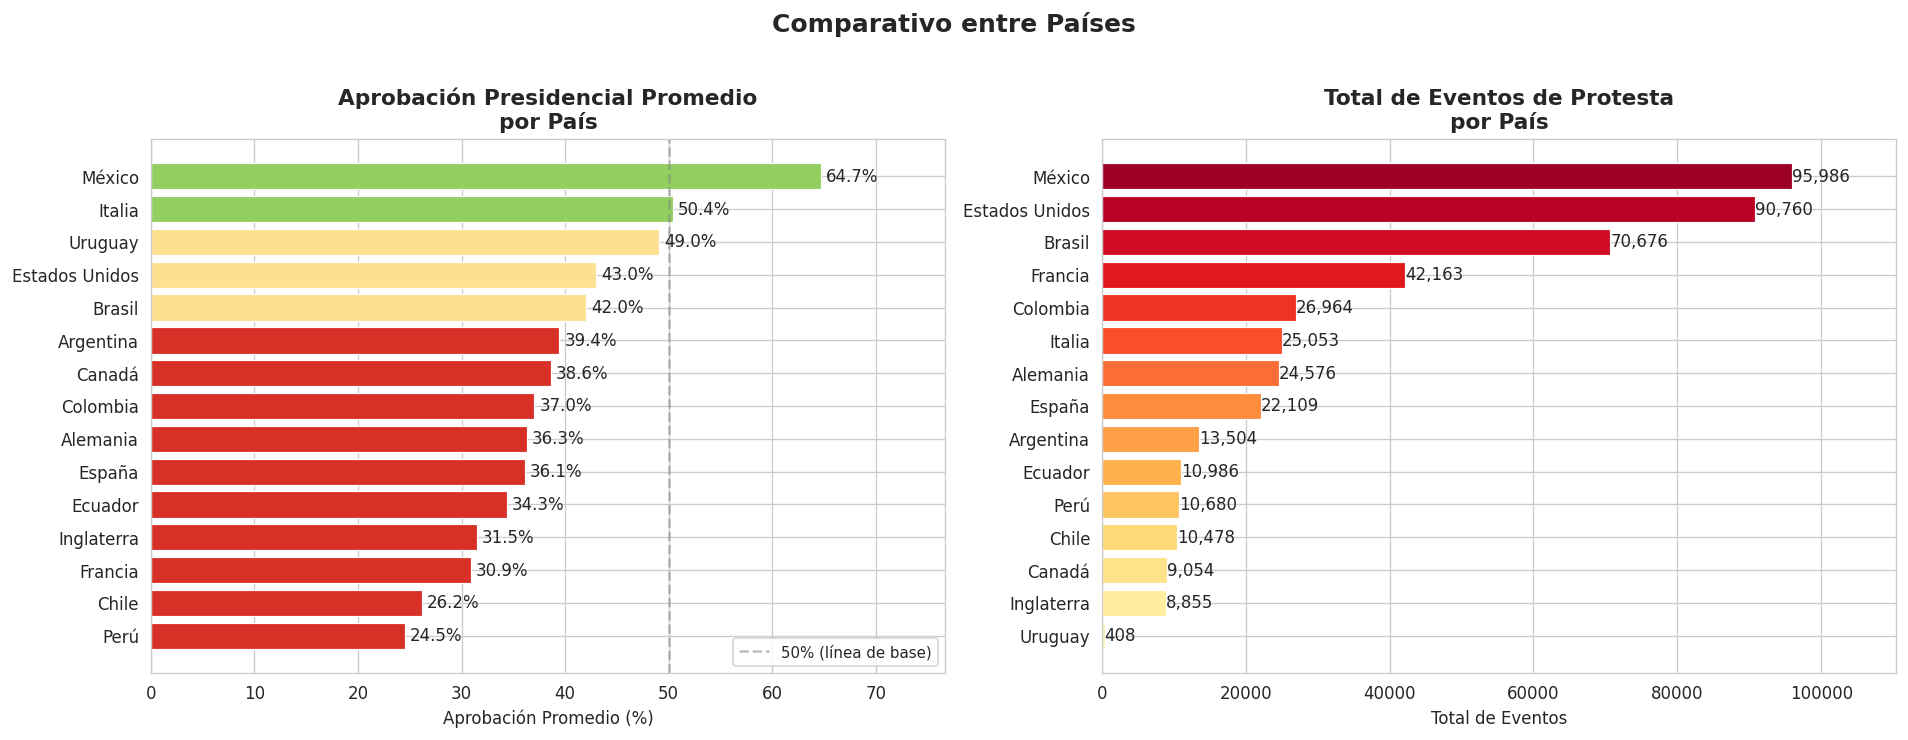

In [ ]:
# --- Comparación: Aprobación Promedio y Protesta Total por País ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ap_prom = df.groupby('País')['Aprobacion'].mean().sort_values(ascending=True)
colors_ap = ['#d73027' if v < 40 else '#fee090' if v < 50 else '#91cf60' for v in ap_prom.values]

axes[0].barh(ap_prom.index, ap_prom.values, color=colors_ap, edgecolor='white', linewidth=0.7)
for i, v in enumerate(ap_prom.values):
    axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
axes[0].axvline(50, color='gray', linestyle='--', alpha=0.5, label='50% (línea de base)')
axes[0].set_title('Aprobación Presidencial Promedio\npor País', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Aprobación Promedio (%)')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, ap_prom.max() + 12)

ps_total = df.groupby('País')['Protestas'].sum().sort_values(ascending=True)
colors_ps = sns.color_palette('YlOrRd', len(ps_total))

axes[1].barh(ps_total.index, ps_total.values, color=colors_ps, edgecolor='white', linewidth=0.7)
for i, v in enumerate(ps_total.values):
    axes[1].text(v + 1, i, f'{int(v):,}', va='center', fontsize=10)
axes[1].set_title('Total de Eventos de Protesta\npor País', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total de Eventos')
axes[1].set_xlim(0, ps_total.max() * 1.15)

plt.suptitle('Comparativo entre Países', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

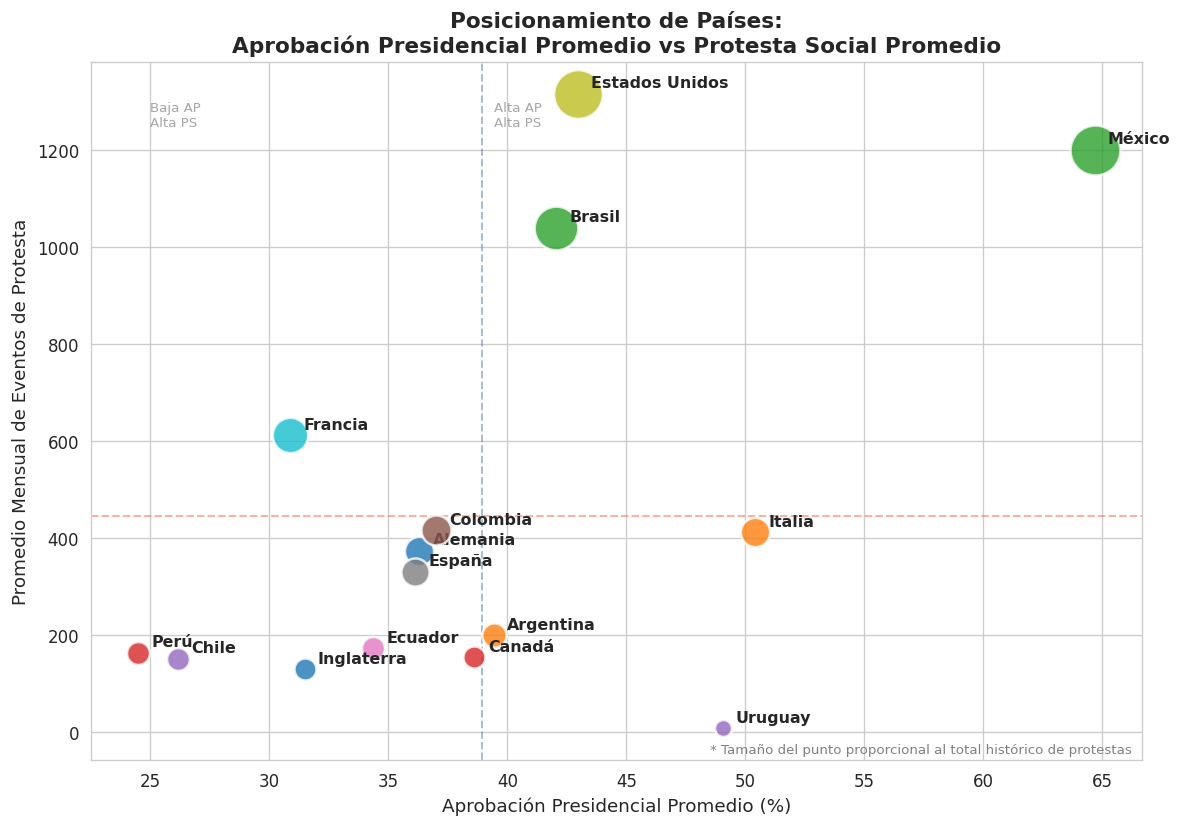

In [ ]:
# --- Gráfico de Posicionamiento: AP vs PS (scatter comparativo) ---
fig, ax = plt.subplots(figsize=(10, 7))

medias = df.groupby('País')[['Aprobacion', 'Protestas']].mean()
totales_ps = df.groupby('País')['Protestas'].sum()

# Tamaño del punto proporcional al total de protestas
sizes = (totales_ps / totales_ps.max() * 800 + 100)
colors = sns.color_palette(PALETTE, len(PAISES))

for i, pais in enumerate(medias.index):
    ax.scatter(medias.loc[pais, 'Aprobacion'], medias.loc[pais, 'Protestas'],
               s=sizes[pais], color=colors[i], alpha=0.8, edgecolors='white',
               linewidth=1.5, zorder=3, label=pais)
    ax.annotate(pais,
                (medias.loc[pais, 'Aprobacion'], medias.loc[pais, 'Protestas']),
                textcoords='offset points', xytext=(8, 4), fontsize=9.5, fontweight='bold')

# Líneas de referencia (medias globales)
ax.axvline(medias['Aprobacion'].mean(), color='steelblue', linestyle='--', alpha=0.5, linewidth=1.2)
ax.axhline(medias['Protestas'].mean(), color='tomato', linestyle='--', alpha=0.5, linewidth=1.2)

# Cuadrantes
ax.text(medias['Aprobacion'].mean() + 0.5, medias['Protestas'].max() * 0.95,
        'Alta AP\nAlta PS', fontsize=8, color='gray', alpha=0.7)
ax.text(medias['Aprobacion'].min() + 0.5, medias['Protestas'].max() * 0.95,
        'Baja AP\nAlta PS', fontsize=8, color='gray', alpha=0.7)

ax.set_title('Posicionamiento de Países:\nAprobación Presidencial Promedio vs Protesta Social Promedio',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Aprobación Presidencial Promedio (%)', fontsize=11)
ax.set_ylabel('Promedio Mensual de Eventos de Protesta', fontsize=11)
ax.text(0.99, 0.01, '* Tamaño del punto proporcional al total histórico de protestas',
        transform=ax.transAxes, fontsize=8, ha='right', color='gray')
plt.tight_layout()
plt.show()

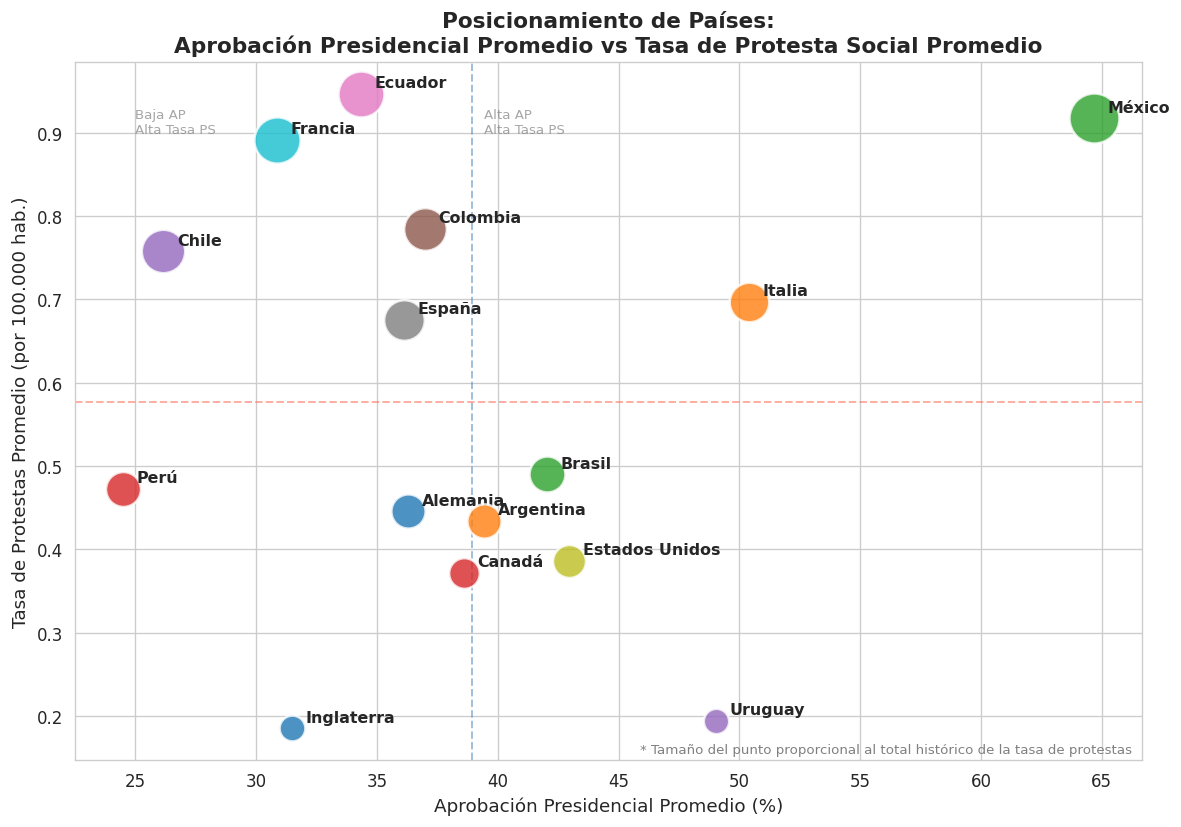

In [ ]:
# --- Gráfico de Posicionamiento: AP vs Tasa de Protestas (scatter comparativo) ---
fig, ax = plt.subplots(figsize=(10, 7))

medias = df.groupby('País')[['Aprobacion', 'Tasa_Protestas']].mean()
totales_ps = df.groupby('País')['Tasa_Protestas'].sum()

# Tamaño del punto proporcional al total de la tasa de protestas
sizes = (totales_ps / totales_ps.max() * 800 + 100)
colors = sns.color_palette(PALETTE, len(PAISES))

for i, pais in enumerate(medias.index):
    ax.scatter(medias.loc[pais, 'Aprobacion'], medias.loc[pais, 'Tasa_Protestas'],
               s=sizes[pais], color=colors[i], alpha=0.8, edgecolors='white',
               linewidth=1.5, zorder=3, label=pais)
    ax.annotate(pais,
                (medias.loc[pais, 'Aprobacion'], medias.loc[pais, 'Tasa_Protestas']),
                textcoords='offset points', xytext=(8, 4), fontsize=9.5, fontweight='bold')

# Líneas de referencia (medias globales)
ax.axvline(medias['Aprobacion'].mean(), color='steelblue', linestyle='--', alpha=0.5, linewidth=1.2)
ax.axhline(medias['Tasa_Protestas'].mean(), color='tomato', linestyle='--', alpha=0.5, linewidth=1.2)

# Cuadrantes
ax.text(medias['Aprobacion'].mean() + 0.5, medias['Tasa_Protestas'].max() * 0.95,
        'Alta AP\nAlta Tasa PS', fontsize=8, color='gray', alpha=0.7)
ax.text(medias['Aprobacion'].min() + 0.5, medias['Tasa_Protestas'].max() * 0.95,
        'Baja AP\nAlta Tasa PS', fontsize=8, color='gray', alpha=0.7)

ax.set_title('Posicionamiento de Países:\nAprobación Presidencial Promedio vs Tasa de Protesta Social Promedio',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Aprobación Presidencial Promedio (%)', fontsize=11)
ax.set_ylabel('Tasa de Protestas Promedio (por 100.000 hab.)', fontsize=11)
ax.text(0.99, 0.01, '* Tamaño del punto proporcional al total histórico de la tasa de protestas',
        transform=ax.transAxes, fontsize=8, ha='right', color='gray')
plt.tight_layout()
plt.show()

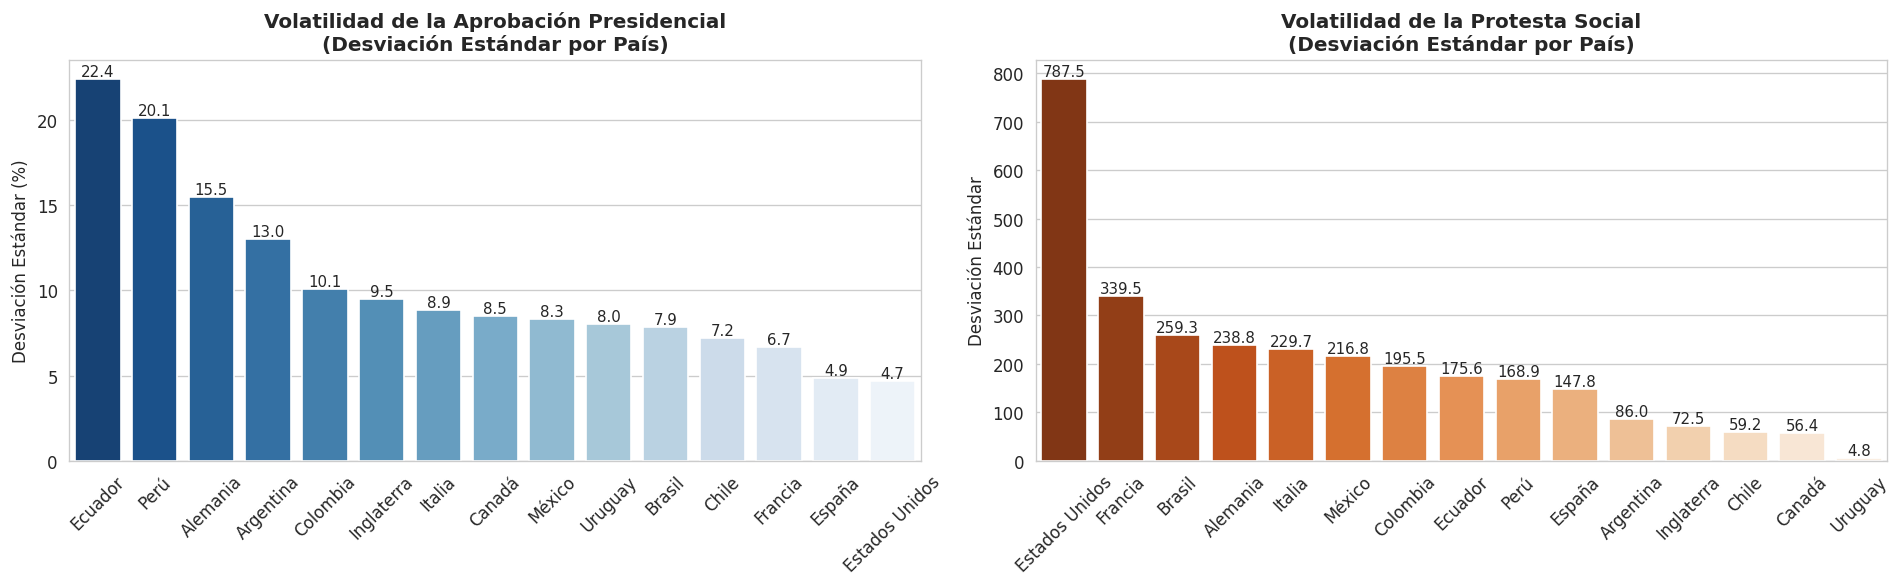

In [ ]:
# --- Variabilidad (Desviación estándar) por país ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ap_std = df.groupby('País')['Aprobacion'].std().sort_values(ascending=False)
ps_std = df.groupby('País')['Protestas'].std().sort_values(ascending=False)

sns.barplot(x=ap_std.index, y=ap_std.values, palette='Blues_r', ax=axes[0])
axes[0].set_title('Volatilidad de la Aprobación Presidencial\n(Desviación Estándar por País)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Desviación Estándar (%)')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

sns.barplot(x=ps_std.index, y=ps_std.values, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Volatilidad de la Protesta Social\n(Desviación Estándar por País)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Desviación Estándar')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

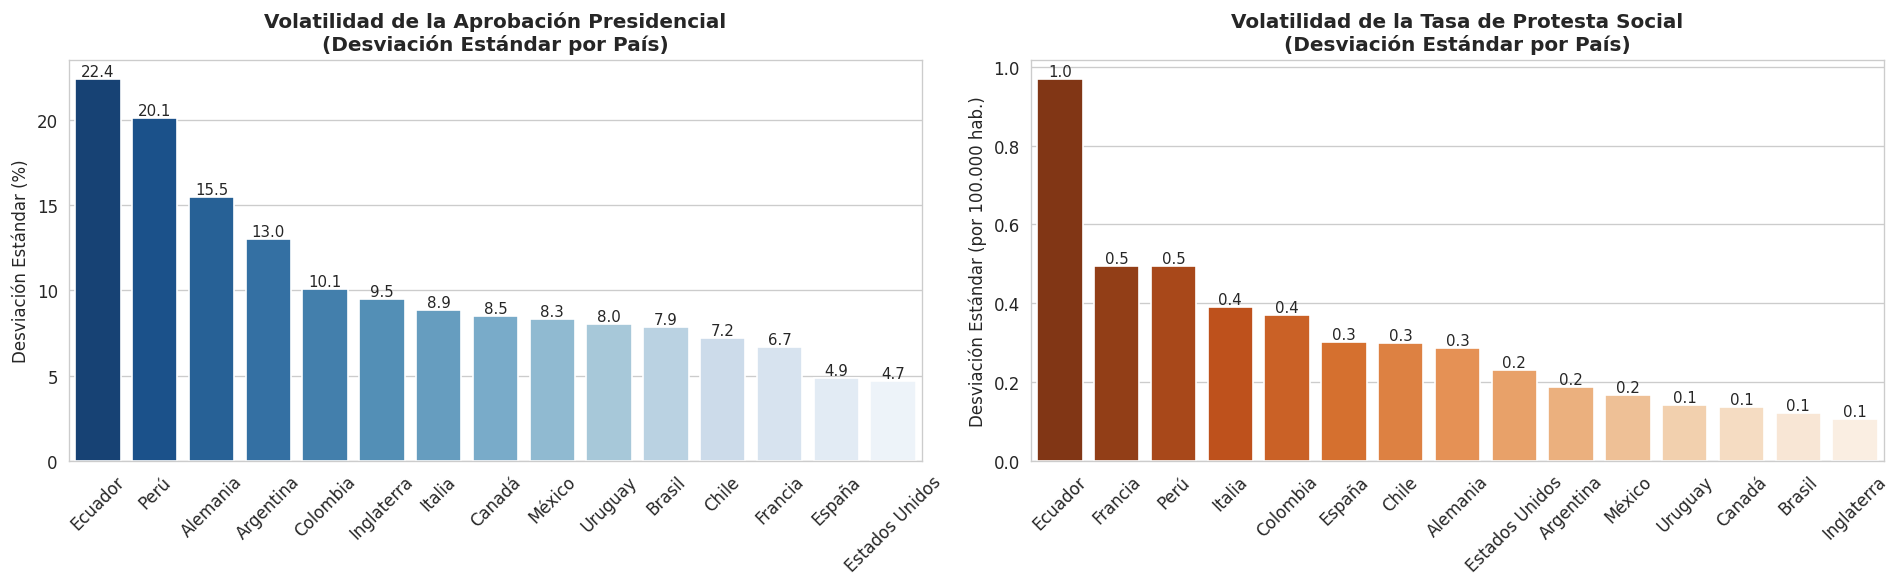

In [ ]:
# --- Variabilidad (Desviación estándar) por país ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ap_std = df.groupby('País')['Aprobacion'].std().sort_values(ascending=False)
ps_std = df.groupby('País')['Tasa_Protestas'].std().sort_values(ascending=False)

sns.barplot(x=ap_std.index, y=ap_std.values, palette='Blues_r', ax=axes[0])
axes[0].set_title('Volatilidad de la Aprobación Presidencial\n(Desviación Estándar por País)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Desviación Estándar (%)')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

sns.barplot(x=ps_std.index, y=ps_std.values, palette='Oranges_r', ax=axes[1])
axes[1].set_title('Volatilidad de la Tasa de Protesta Social\n(Desviación Estándar por País)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Desviación Estándar (por 100.000 hab.)')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

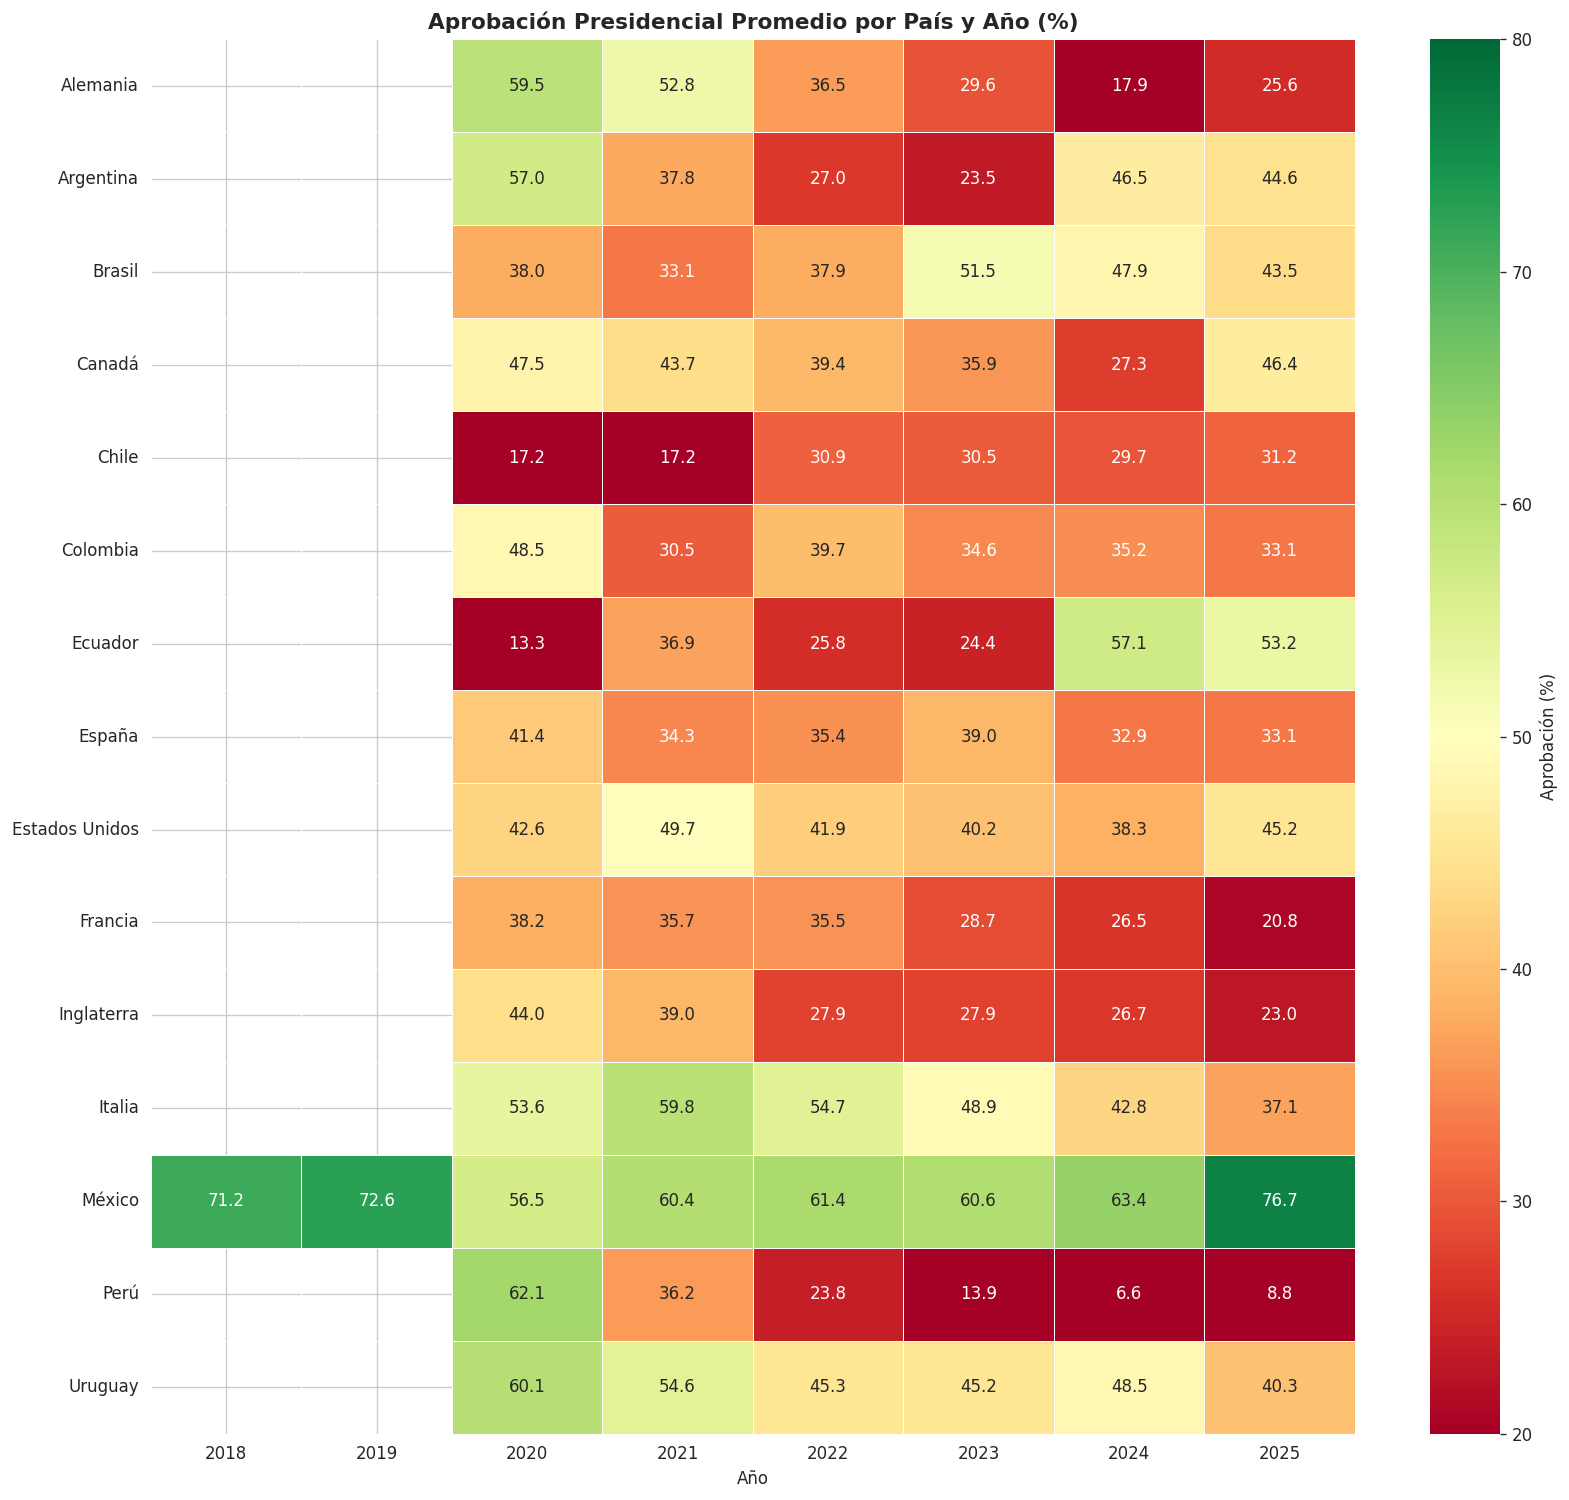

In [ ]:
# --- Heatmap: Aprobación Promedio por Año y País ---
pivot_ap = df.pivot_table(index='País', columns='Año', values='Aprobacion', aggfunc='mean').round(1)

fig, ax = plt.subplots(figsize=(14, max(5, len(PAISES) * 0.7)))
sns.heatmap(pivot_ap, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Aprobación (%)'},
            vmin=20, vmax=80)
ax.set_title('Aprobación Presidencial Promedio por País y Año (%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

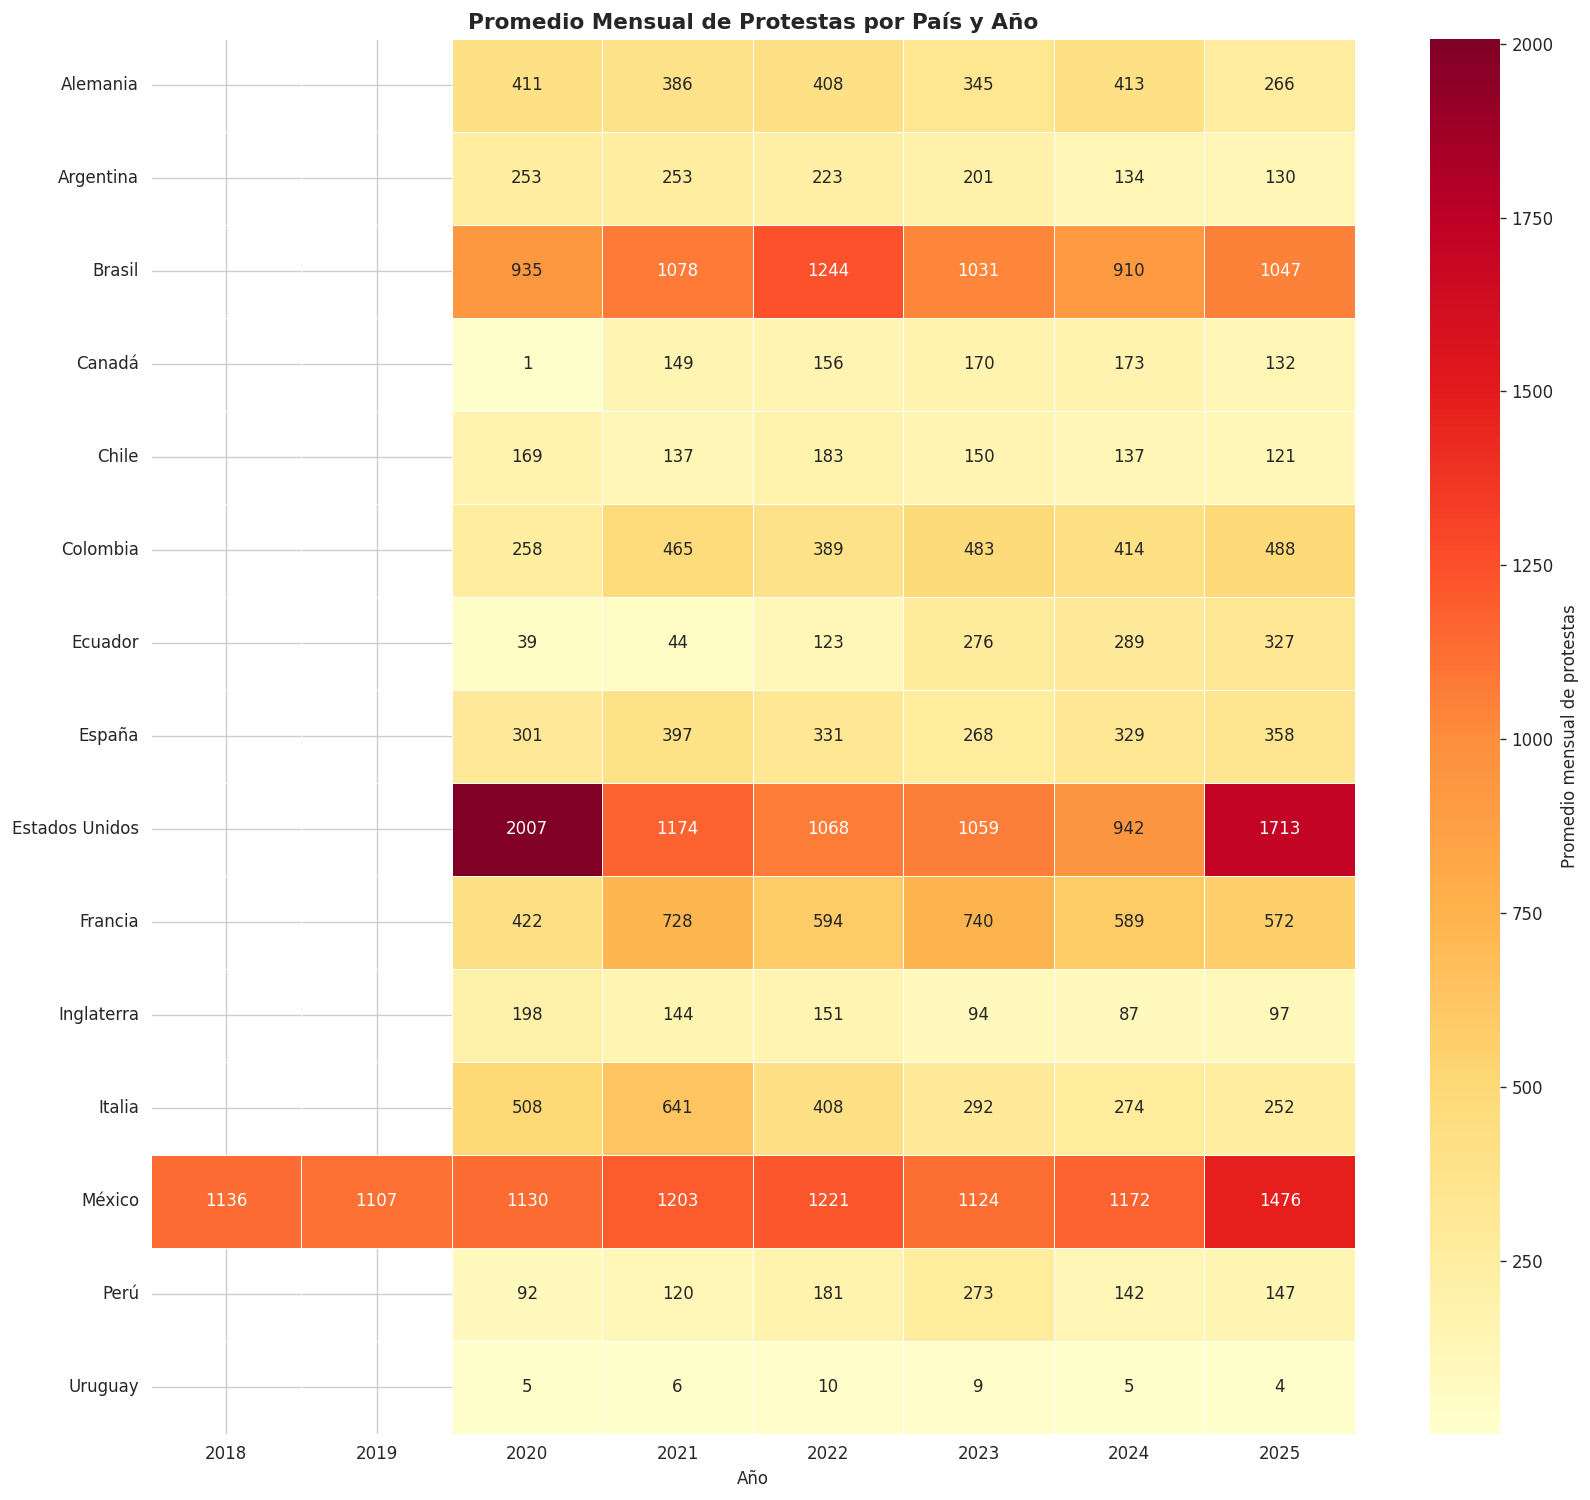

In [ ]:
# --- Heatmap: Protesta Social Promedio por Año y País ---
pivot_ps = df.pivot_table(index='País', columns='Año', values='Protestas', aggfunc='mean').round(0)

fig, ax = plt.subplots(figsize=(14, max(5, len(PAISES) * 0.7)))
sns.heatmap(pivot_ps, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Promedio mensual de protestas'})
ax.set_title('Promedio Mensual de Protestas por País y Año', fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

---
## 4. Series de Tiempo
### 4.1 Series individuales por País (Aprobación + Protestas superpuestas)

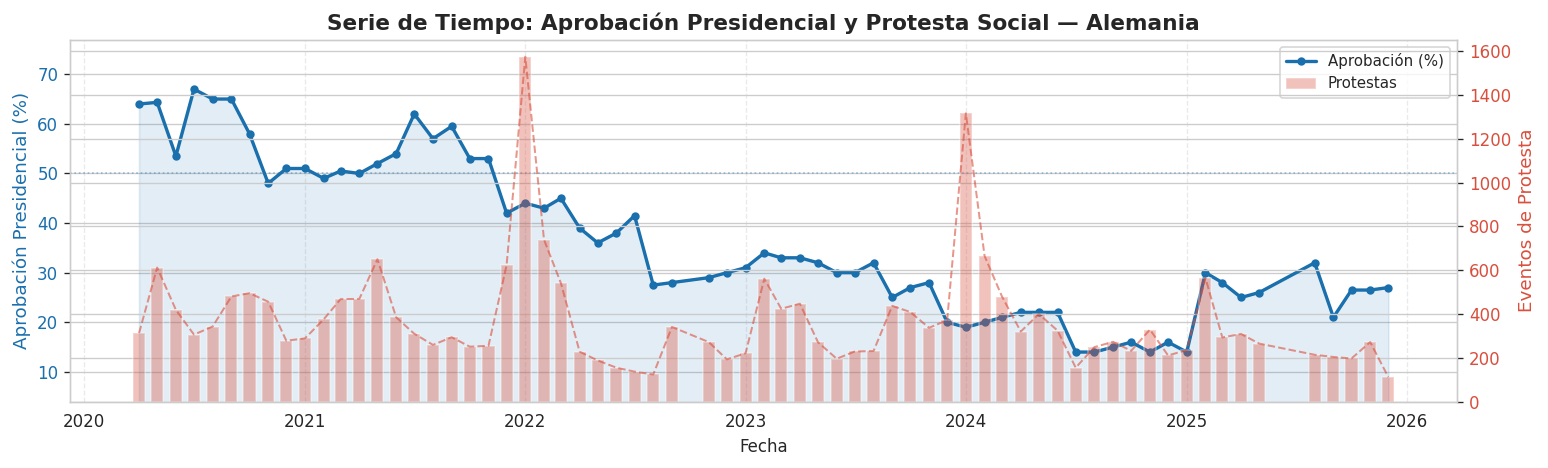

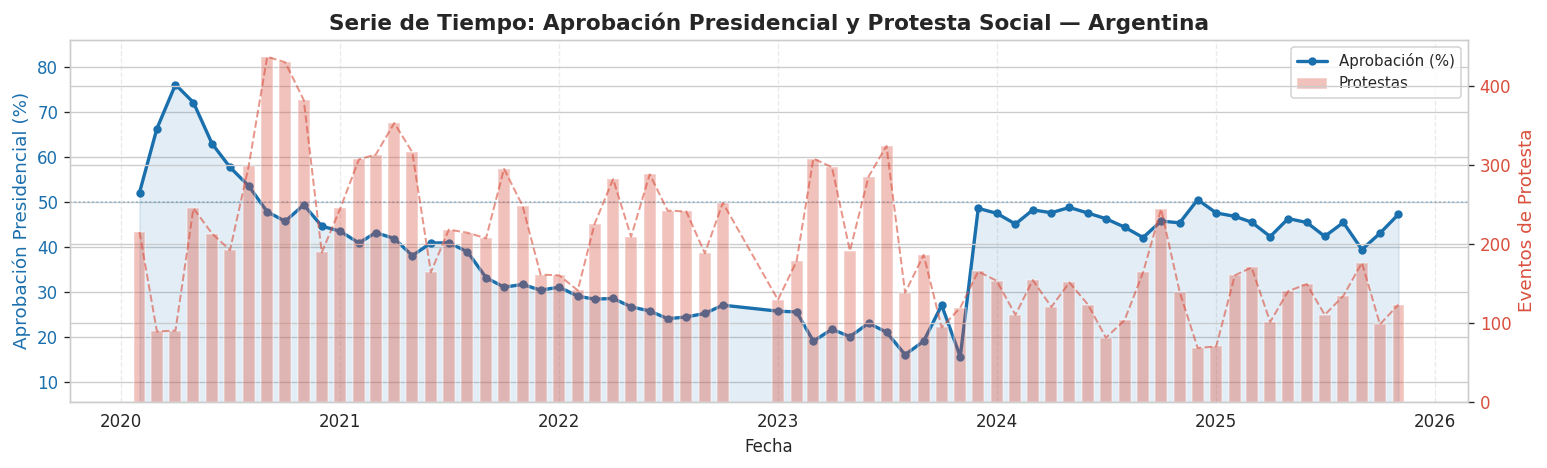

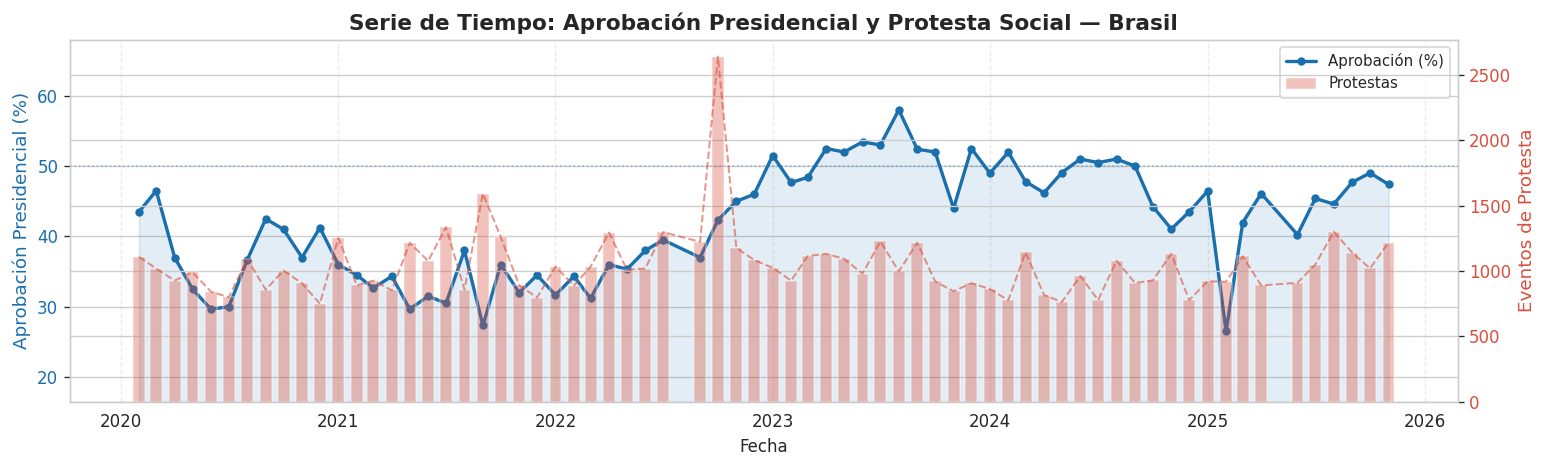

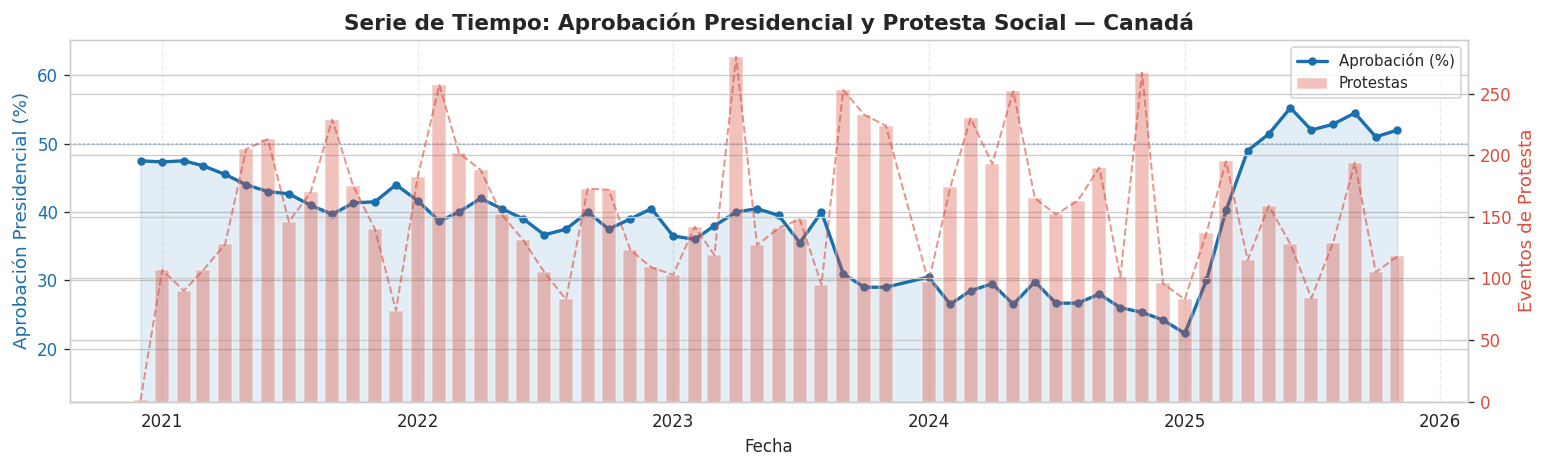

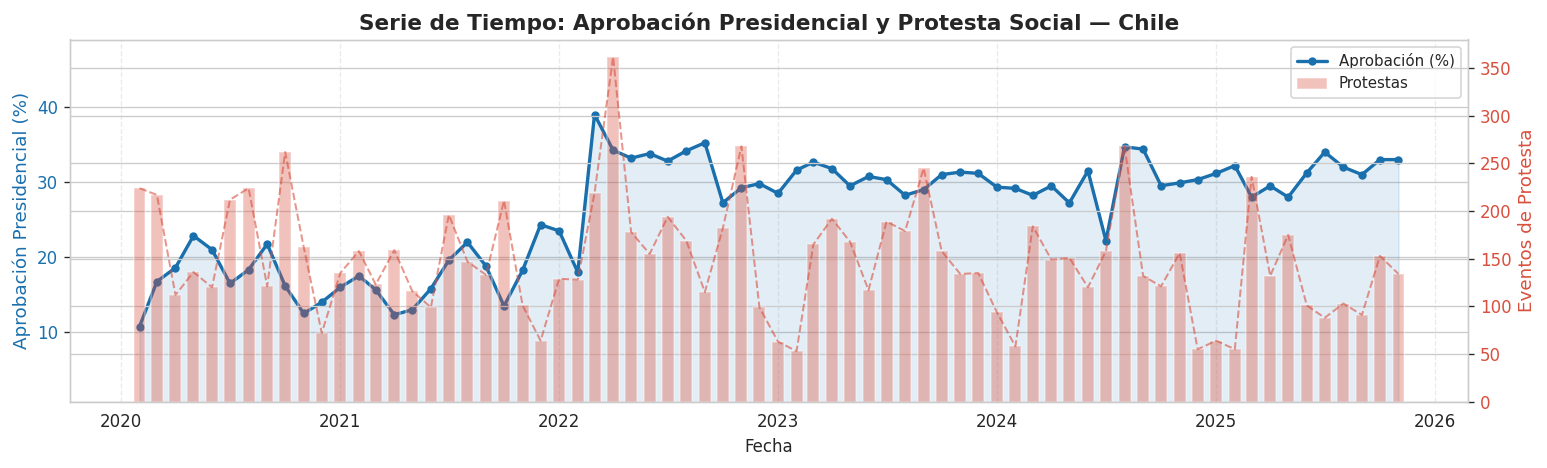

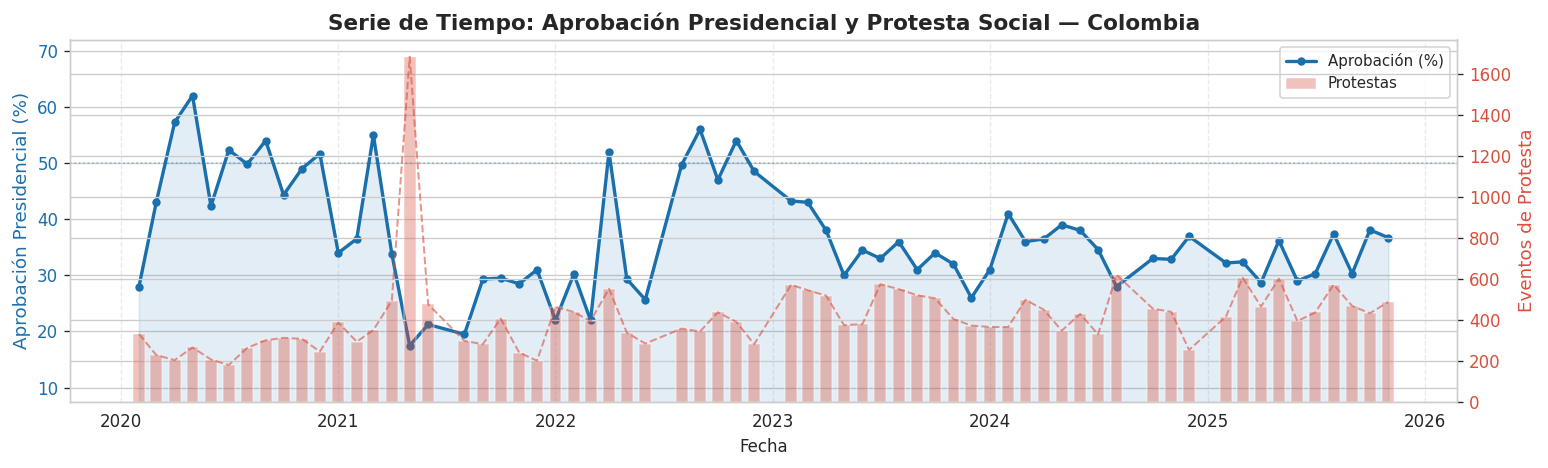

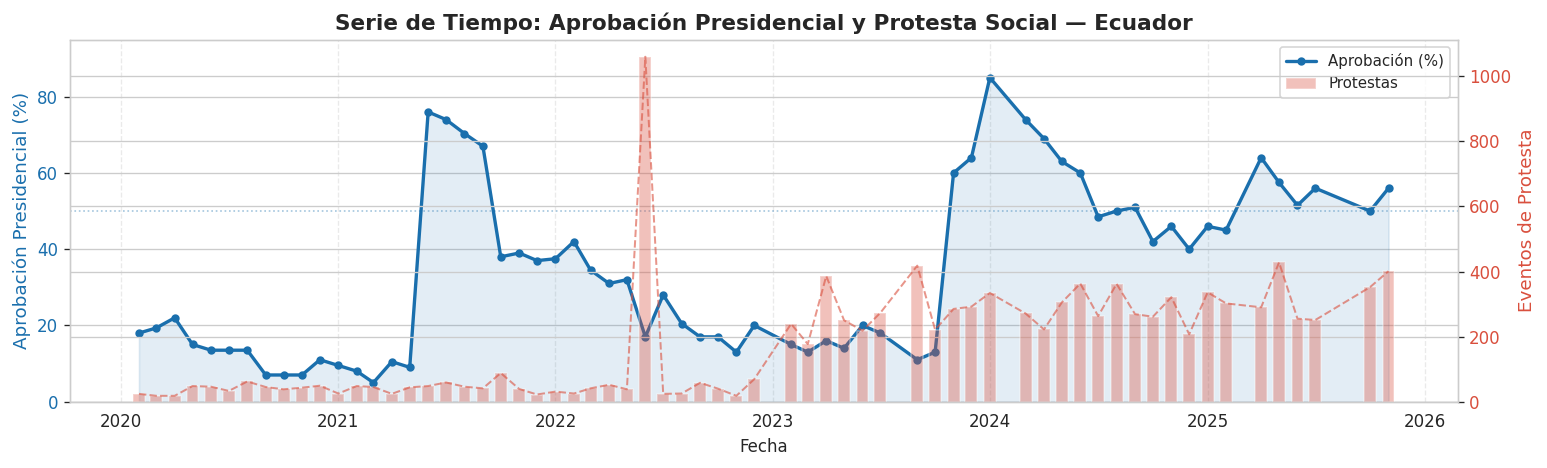

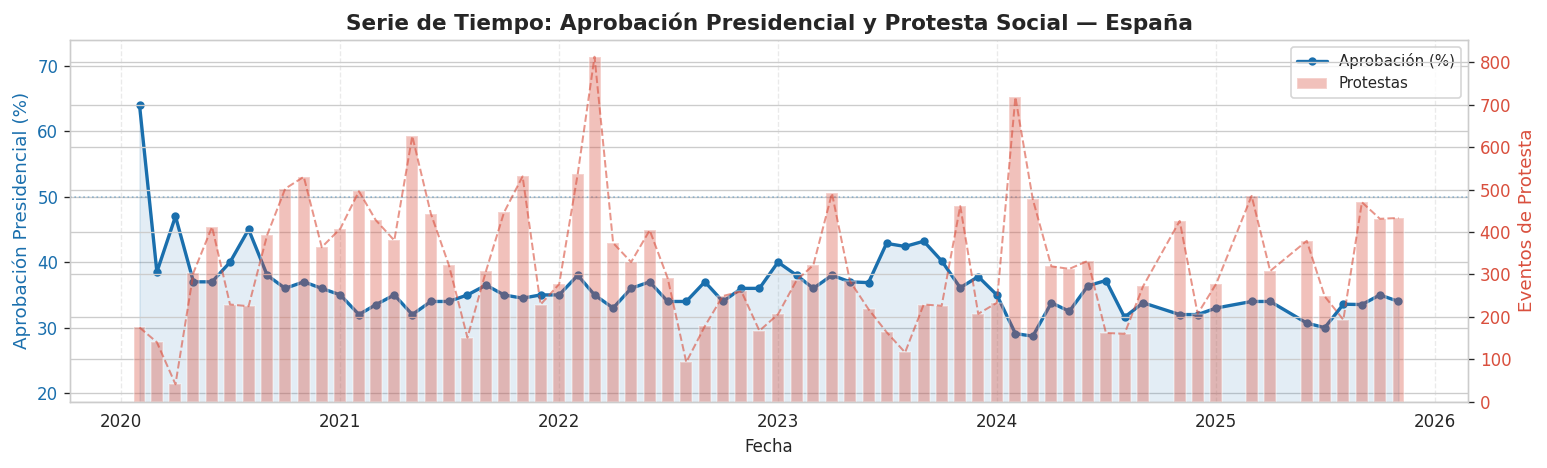

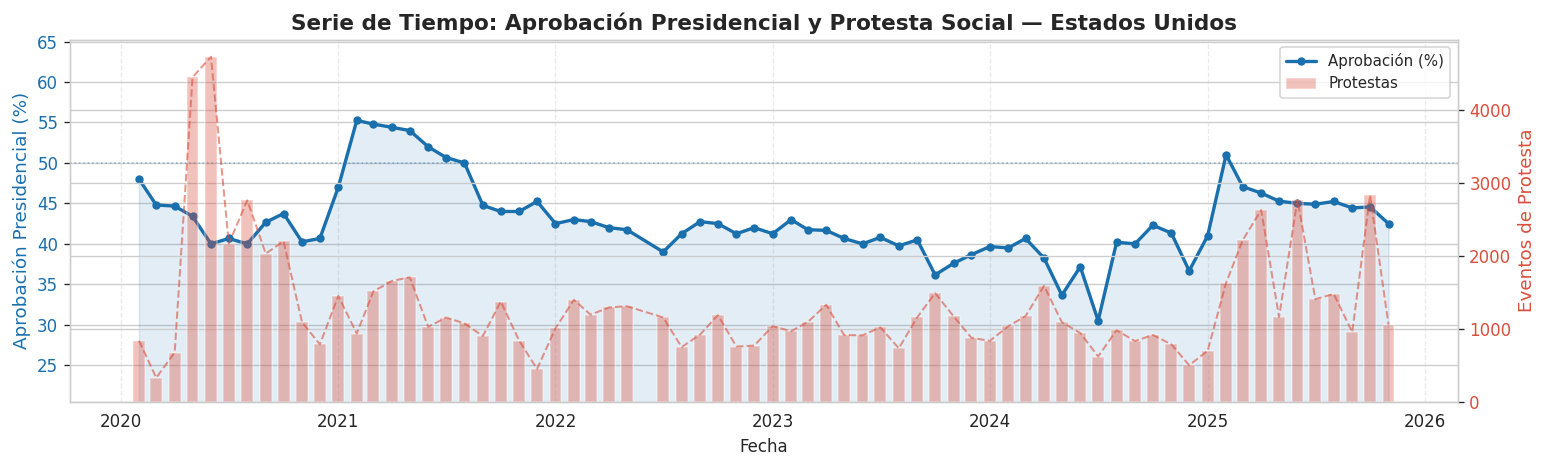

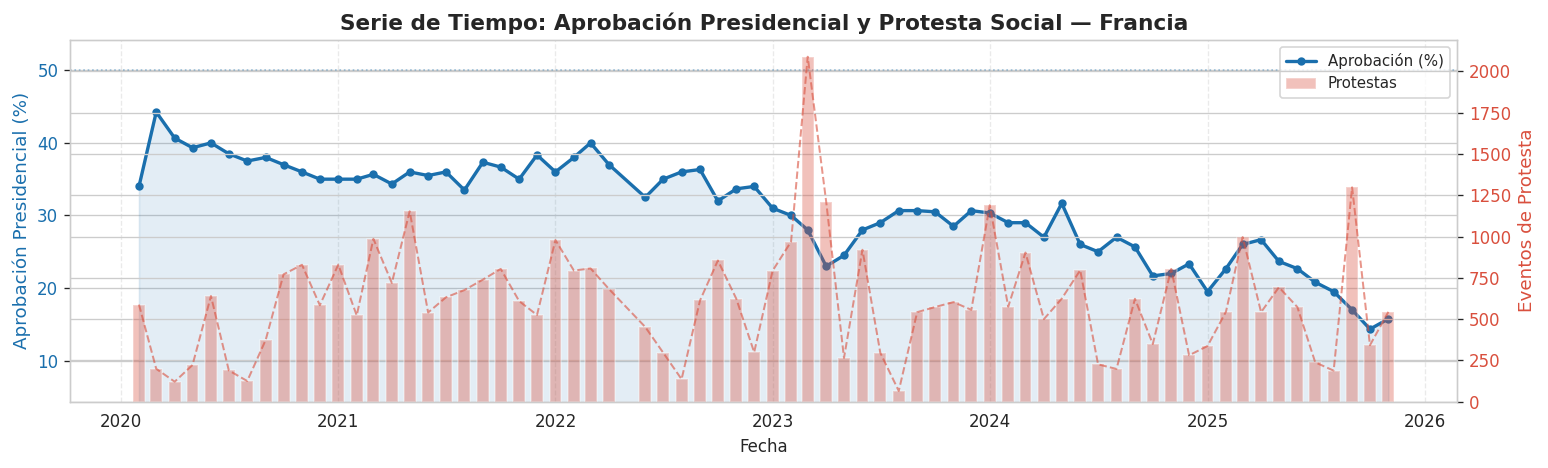

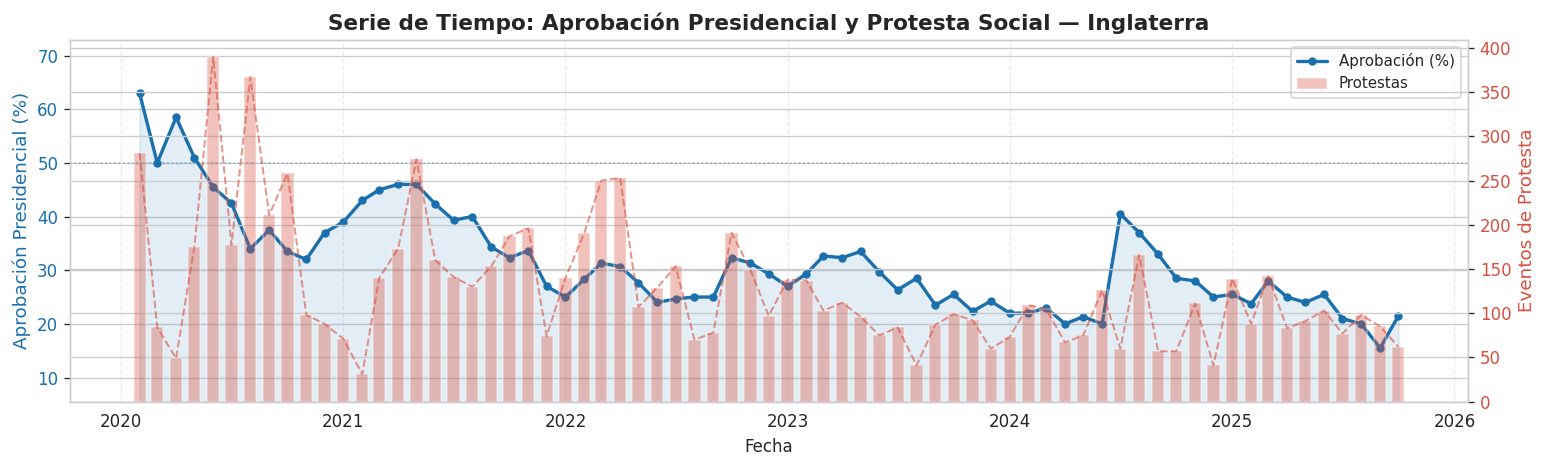

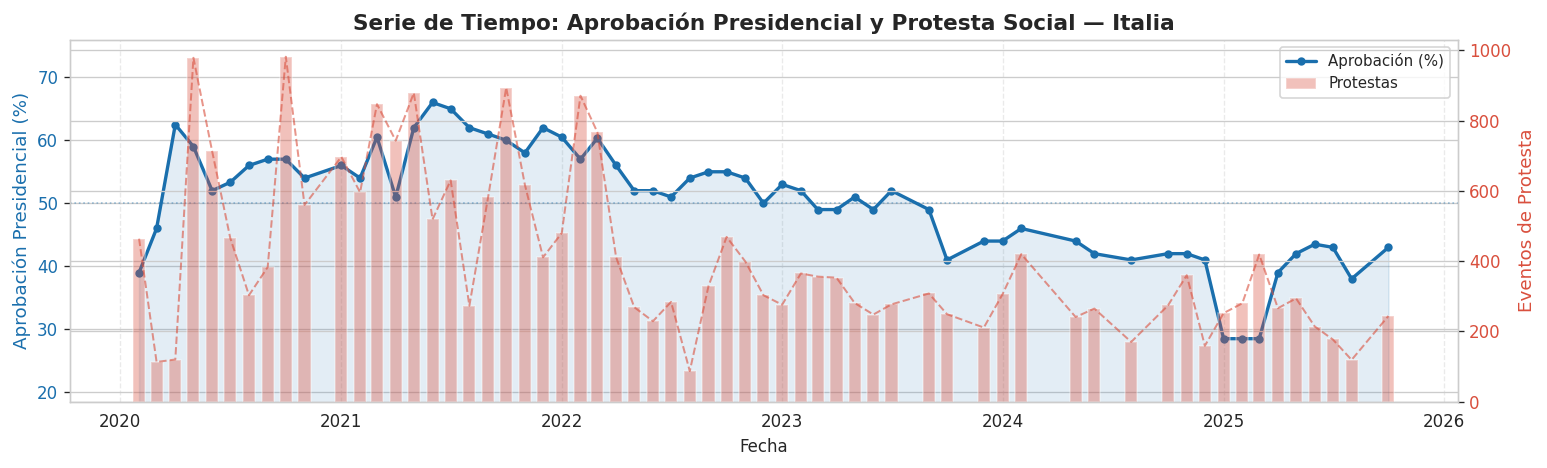

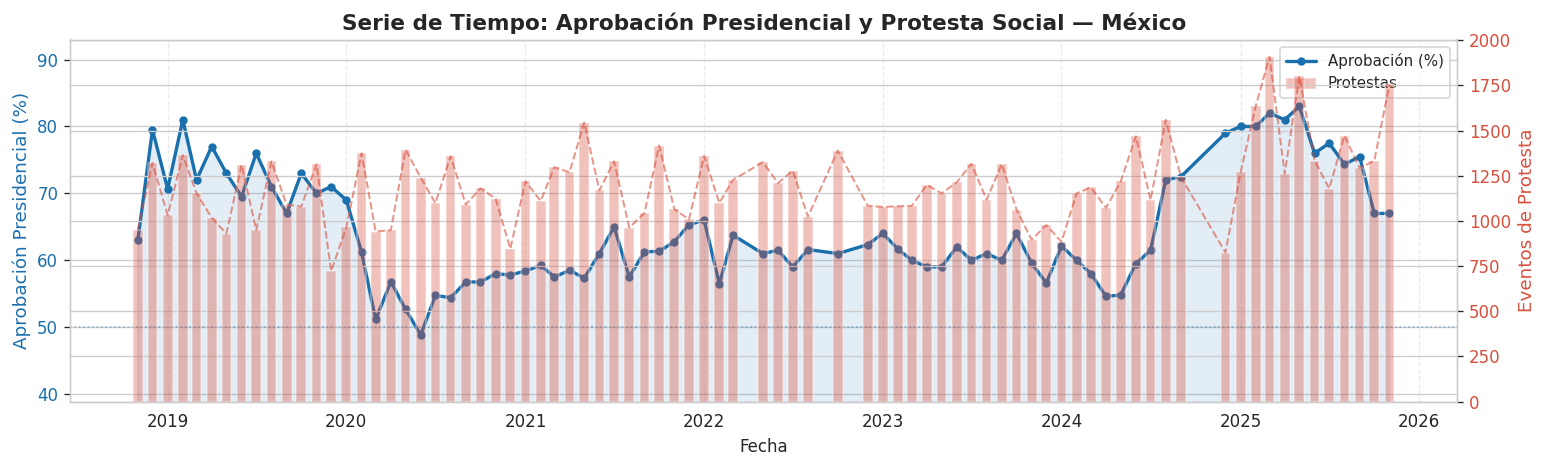

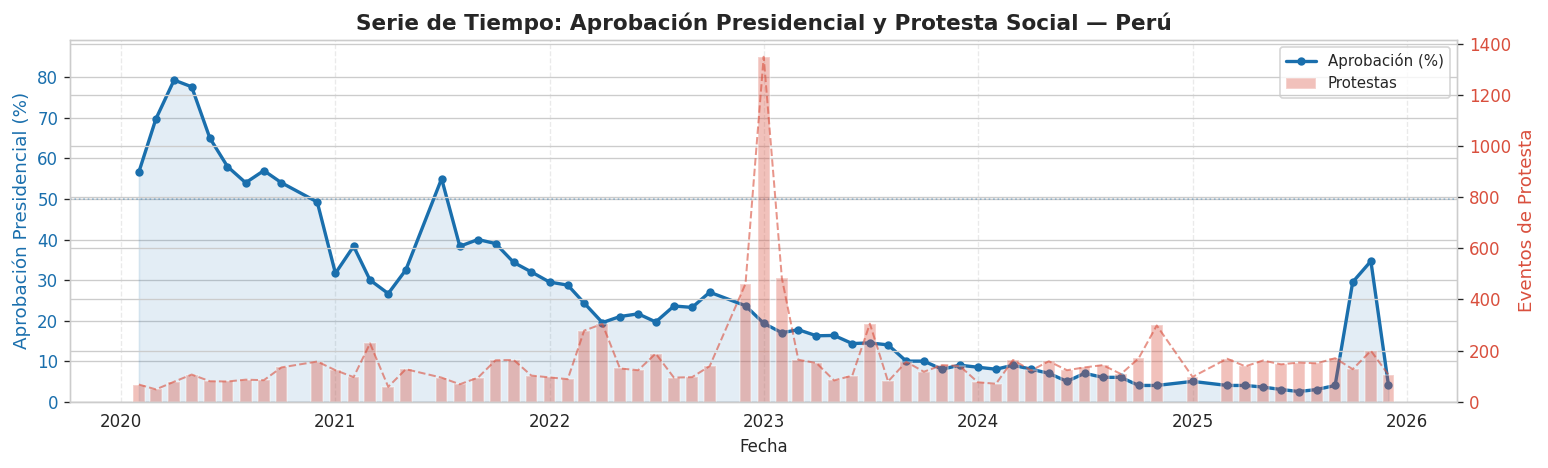

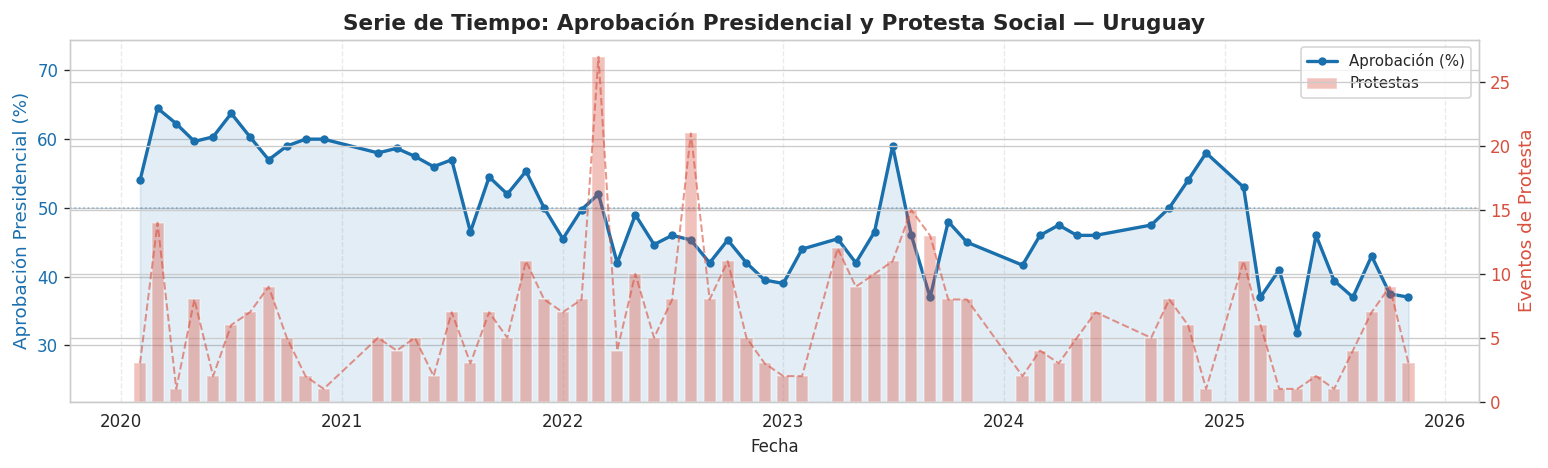

In [ ]:
for pais in PAISES:
    sub = df[df['País'] == pais].sort_values('Fecha').dropna(subset=['Fecha'])
    if len(sub) < 3:
        continue

    fig, ax1 = plt.subplots(figsize=(13, 4))

    # Eje izquierdo: Aprobación
    color_ap = '#1a6fad'
    ax1.plot(sub['Fecha'], sub['Aprobacion'], color=color_ap, linewidth=2,
             marker='o', markersize=4, label='Aprobación (%)', zorder=3)
    ax1.fill_between(sub['Fecha'], sub['Aprobacion'], alpha=0.12, color=color_ap)
    ax1.axhline(50, color=color_ap, linestyle=':', alpha=0.4, linewidth=1)
    ax1.set_ylabel('Aprobación Presidencial (%)', color=color_ap, fontsize=11)
    ax1.tick_params(axis='y', labelcolor=color_ap)
    ax1.set_ylim(
        max(0, sub['Aprobacion'].min() - 10),
        min(100, sub['Aprobacion'].max() + 10)
    )

    # Eje derecho: Protestas
    ax2 = ax1.twinx()
    color_ps = '#d94f3d'
    ax2.bar(sub['Fecha'], sub['Protestas'], width=20, alpha=0.35,
            color=color_ps, label='Protestas', zorder=2)
    ax2.plot(sub['Fecha'], sub['Protestas'], color=color_ps, linewidth=1.2,
             linestyle='--', alpha=0.6)
    ax2.set_ylabel('Eventos de Protesta', color=color_ps, fontsize=11)
    ax2.tick_params(axis='y', labelcolor=color_ps)

    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)

    ax1.set_title(f'Serie de Tiempo: Aprobación Presidencial y Protesta Social — {pais}',
                  fontsize=13, fontweight='bold')
    ax1.set_xlabel('Fecha')
    ax1.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

### 4.2 Panel Comparativo de Series de Tiempo (todos los países)

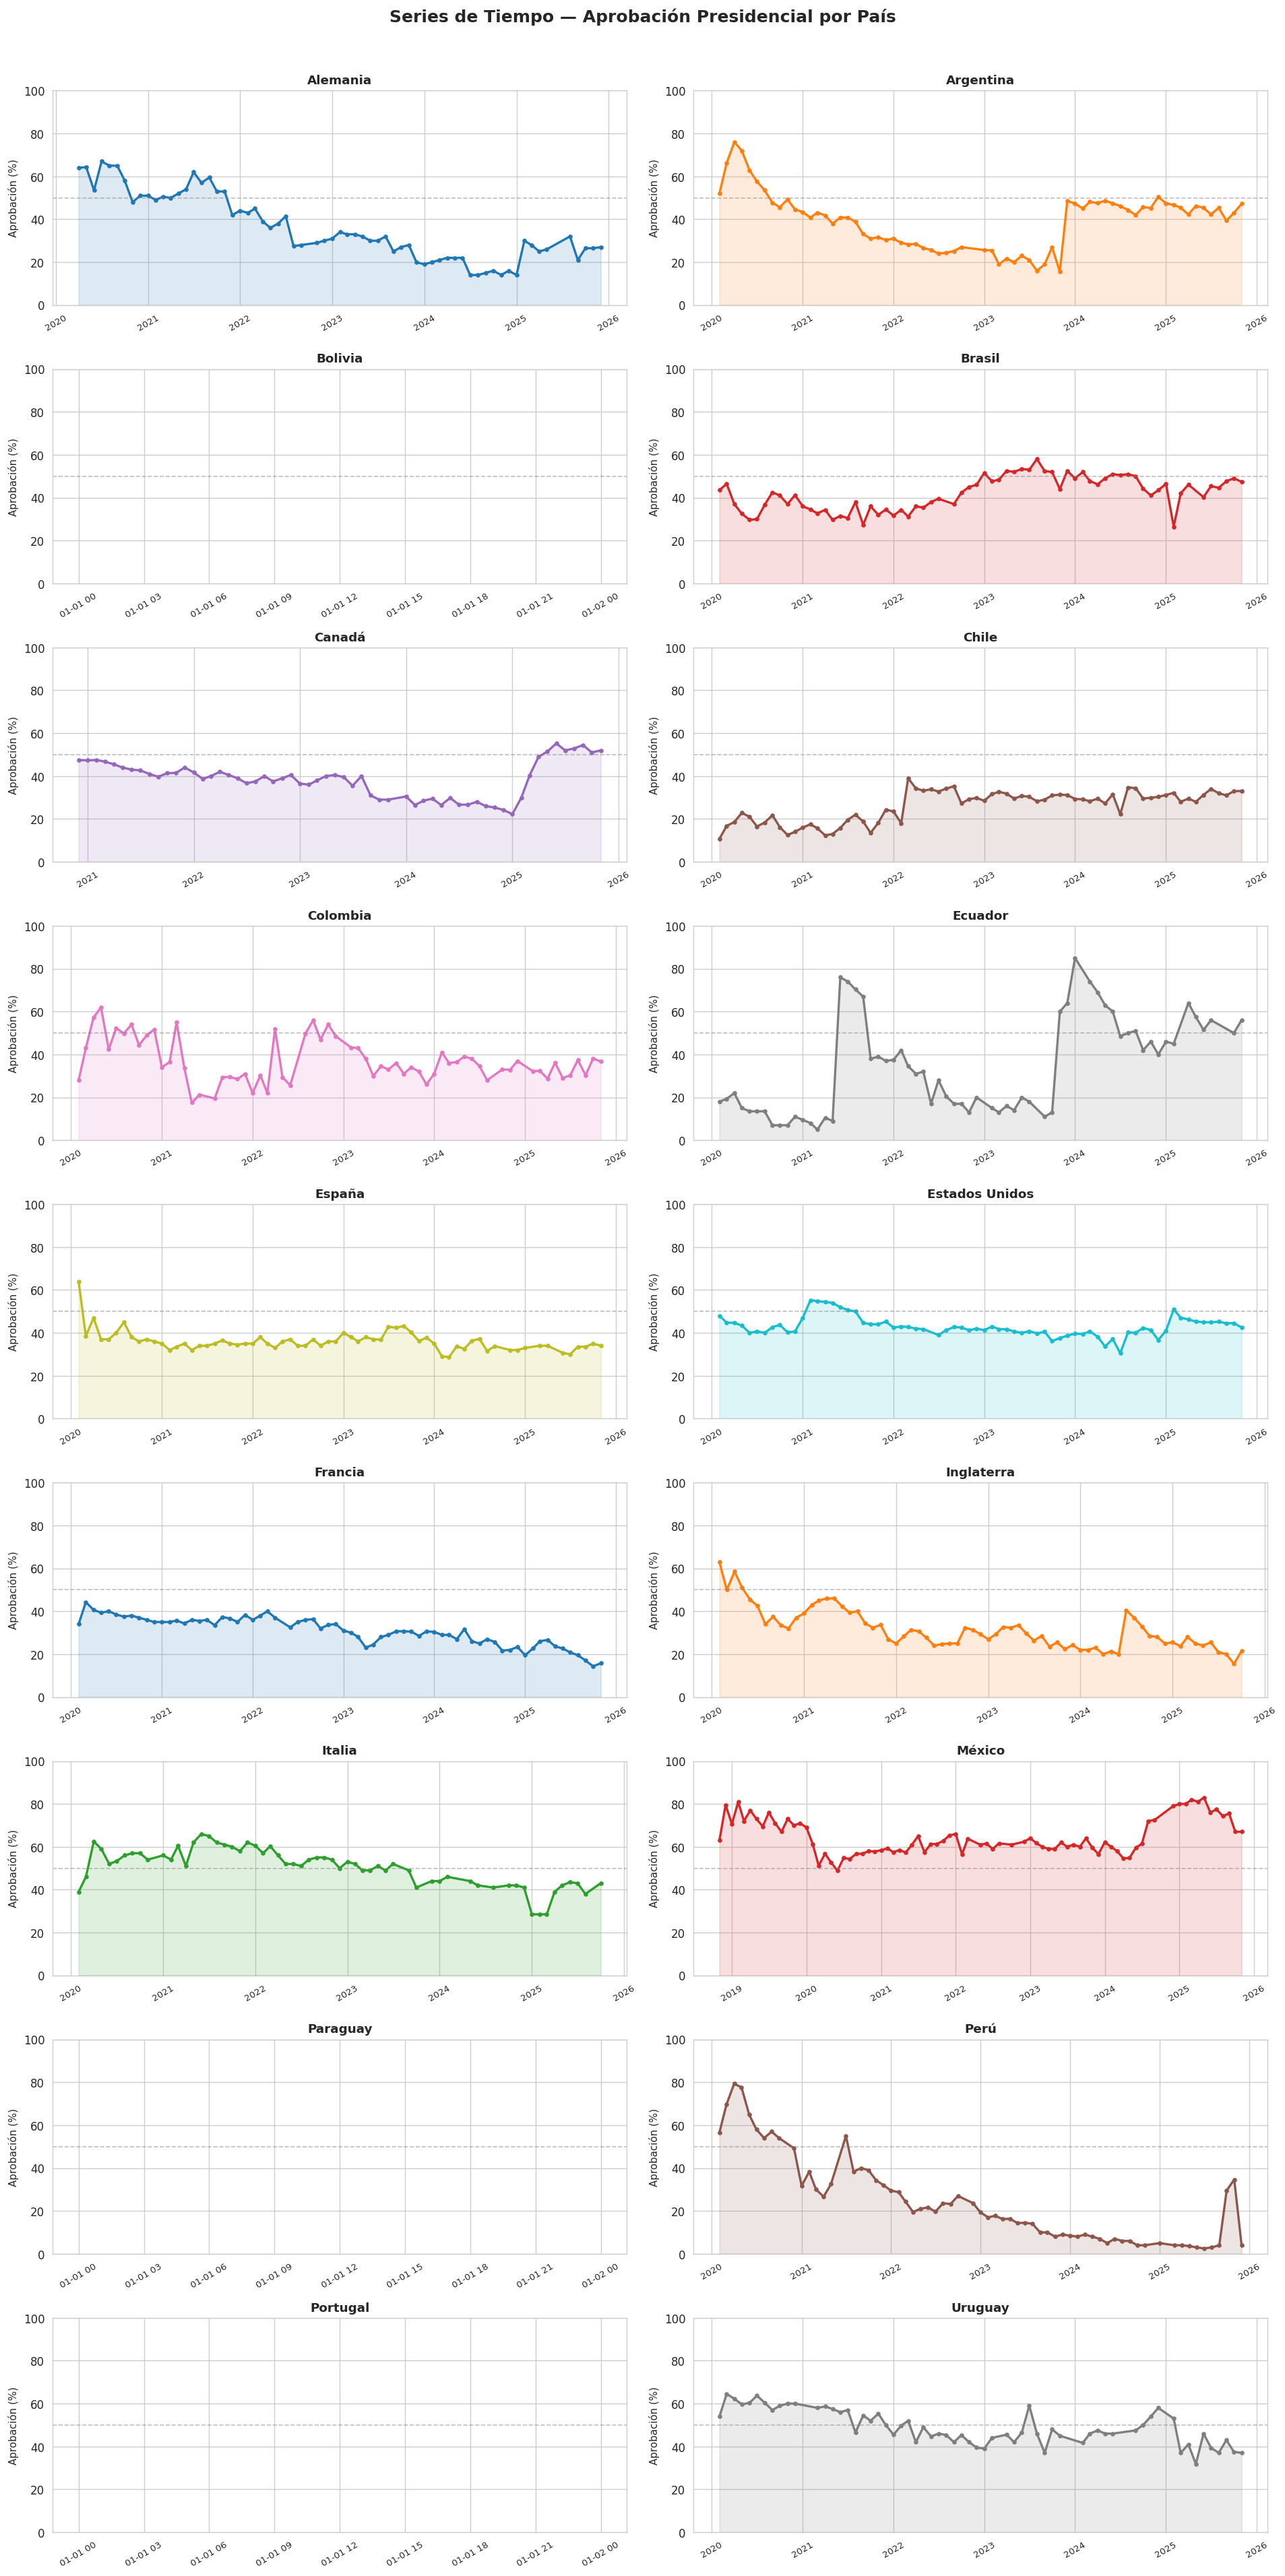

In [ ]:
# Panel: Aprobación Presidencial — todos los países
n = len(PAISES)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharex=False)
axes_flat = axes.flatten() if n > 1 else [axes]

colors = sns.color_palette(PALETTE, n)

for i, pais in enumerate(PAISES):
    ax = axes_flat[i]
    sub = df[df['País'] == pais].sort_values('Fecha').dropna(subset=['Fecha'])
    ax.plot(sub['Fecha'], sub['Aprobacion'], color=colors[i], linewidth=2, marker='o', markersize=3)
    ax.fill_between(sub['Fecha'], sub['Aprobacion'], alpha=0.15, color=colors[i])
    ax.axhline(50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title(pais, fontsize=11, fontweight='bold')
    ax.set_ylabel('Aprobación (%)', fontsize=9)
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

# Ocultar ejes sobrantes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Series de Tiempo — Aprobación Presidencial por País', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

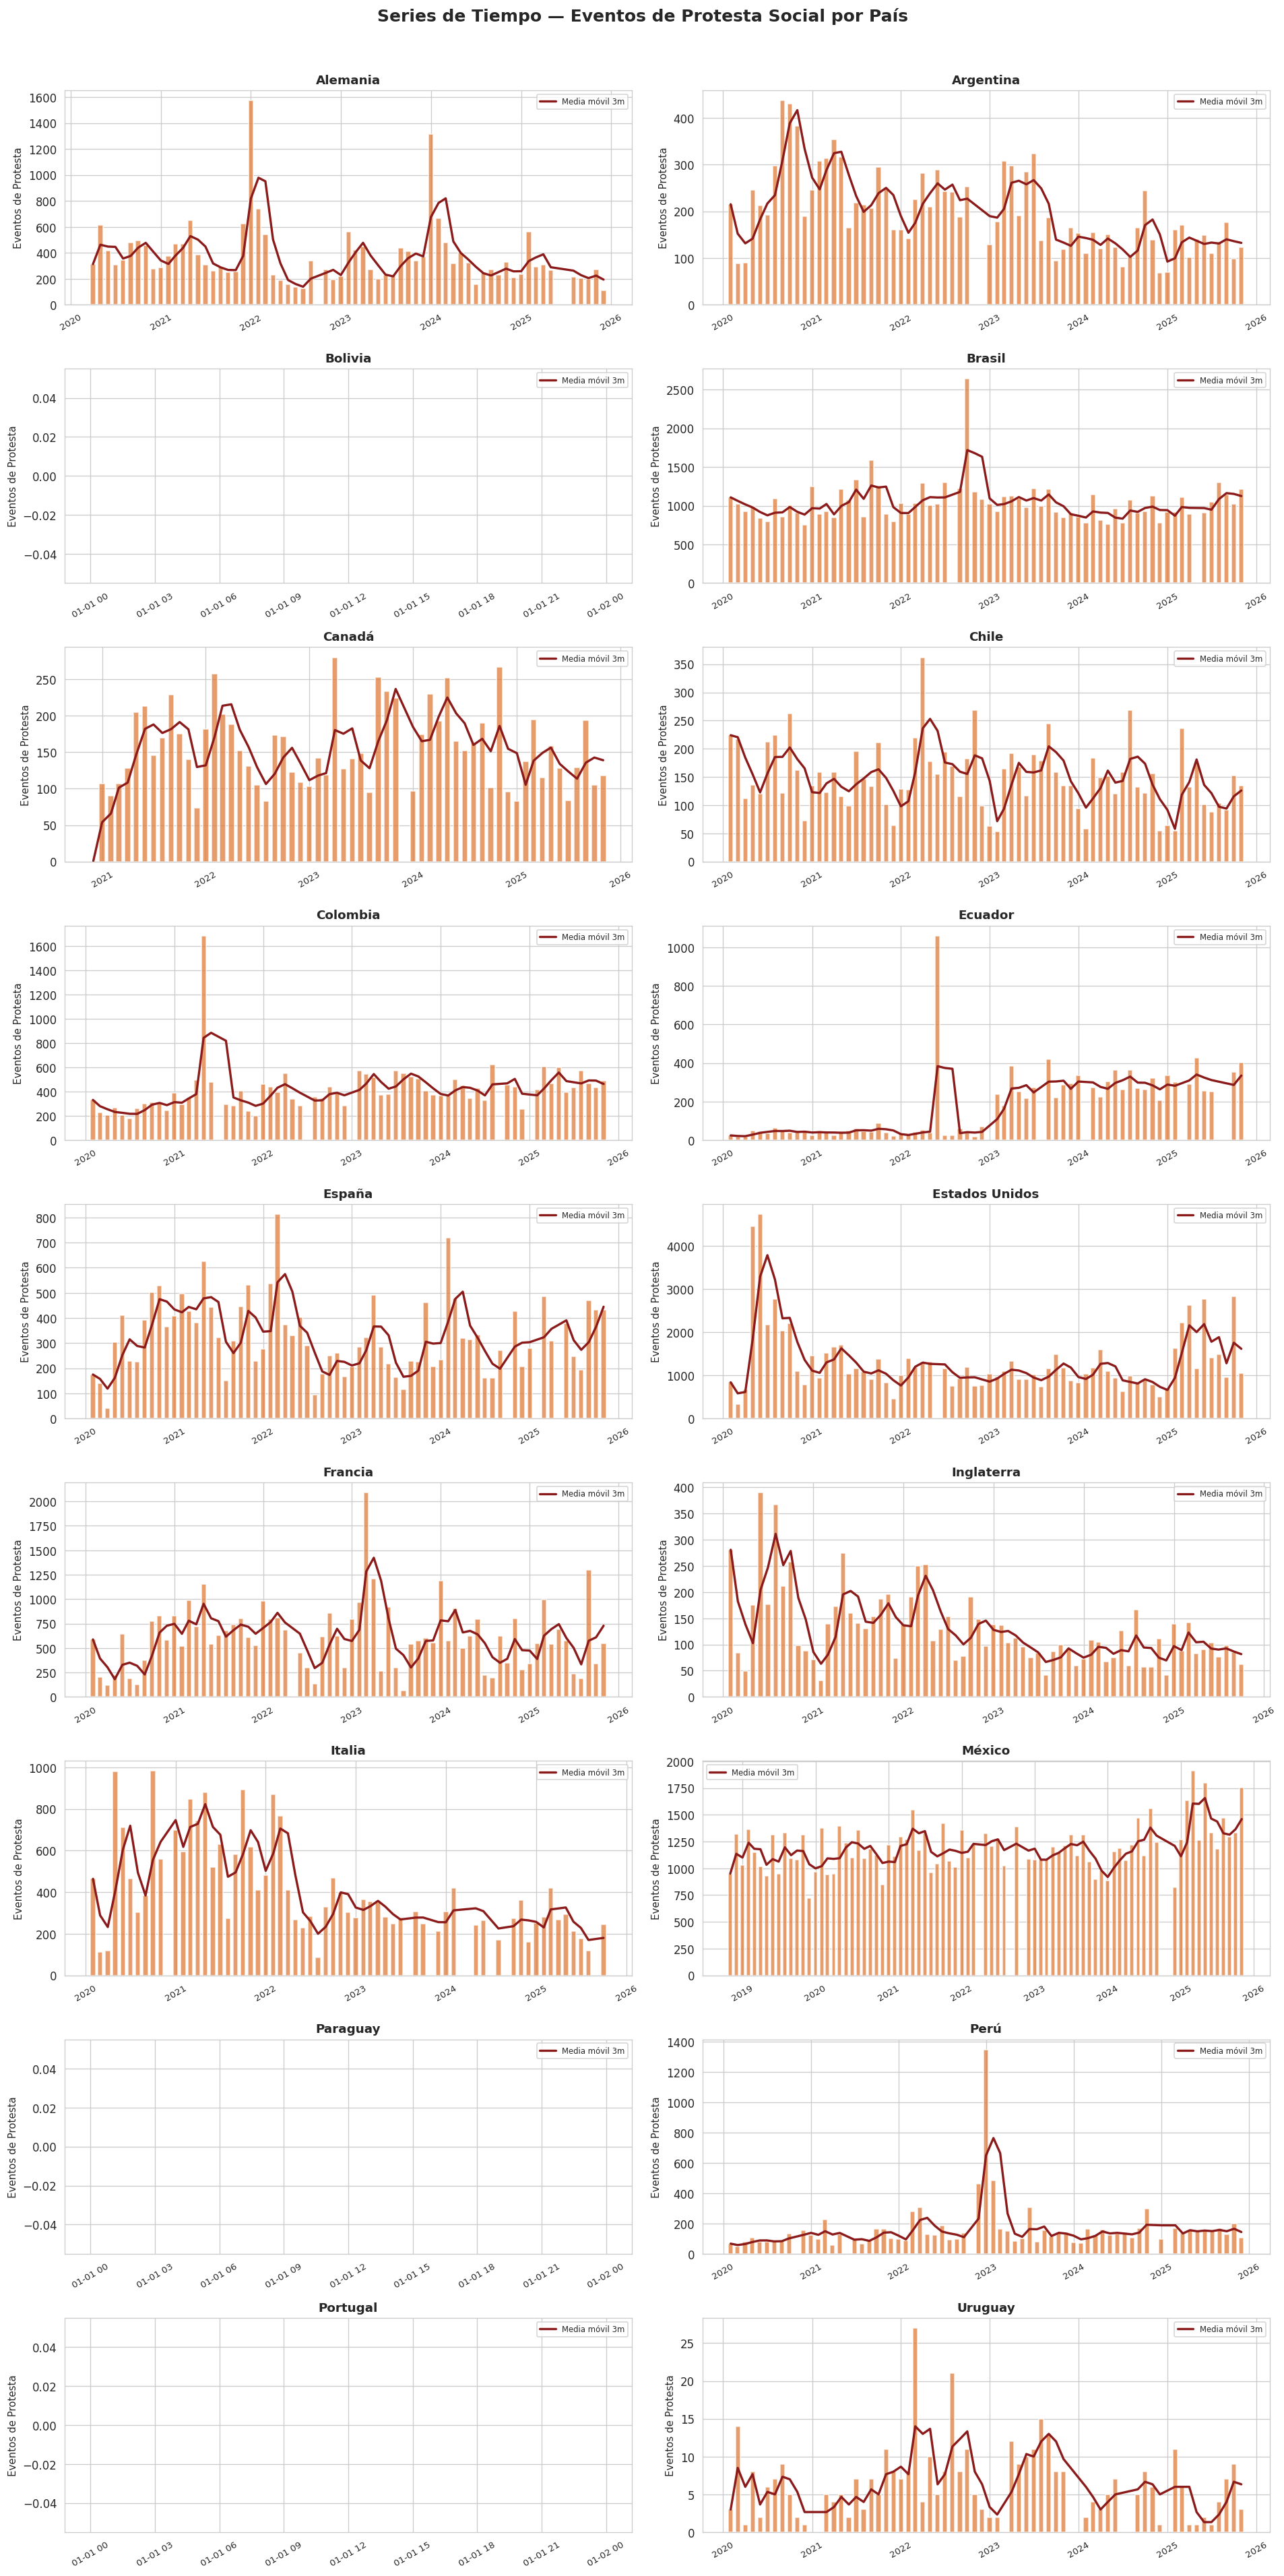

In [ ]:
# Panel: Protesta Social — todos los países
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5), sharex=False)
axes_flat = axes.flatten() if n > 1 else [axes]

for i, pais in enumerate(PAISES):
    ax = axes_flat[i]
    sub = df[df['País'] == pais].sort_values('Fecha').dropna(subset=['Fecha'])
    ax.bar(sub['Fecha'], sub['Protestas'], width=20, color='#e07b39', alpha=0.75, edgecolor='white')
    ax.plot(sub['Fecha'], sub['Protestas'].rolling(3, min_periods=1).mean(),
            color='#8b1a1a', linewidth=2, label='Media móvil 3m')
    ax.set_title(pais, fontsize=11, fontweight='bold')
    ax.set_ylabel('Eventos de Protesta', fontsize=9)
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Series de Tiempo — Eventos de Protesta Social por País', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.3 Serie Temporal Comparativa Multivariable (todos los países en un mismo gráfico)

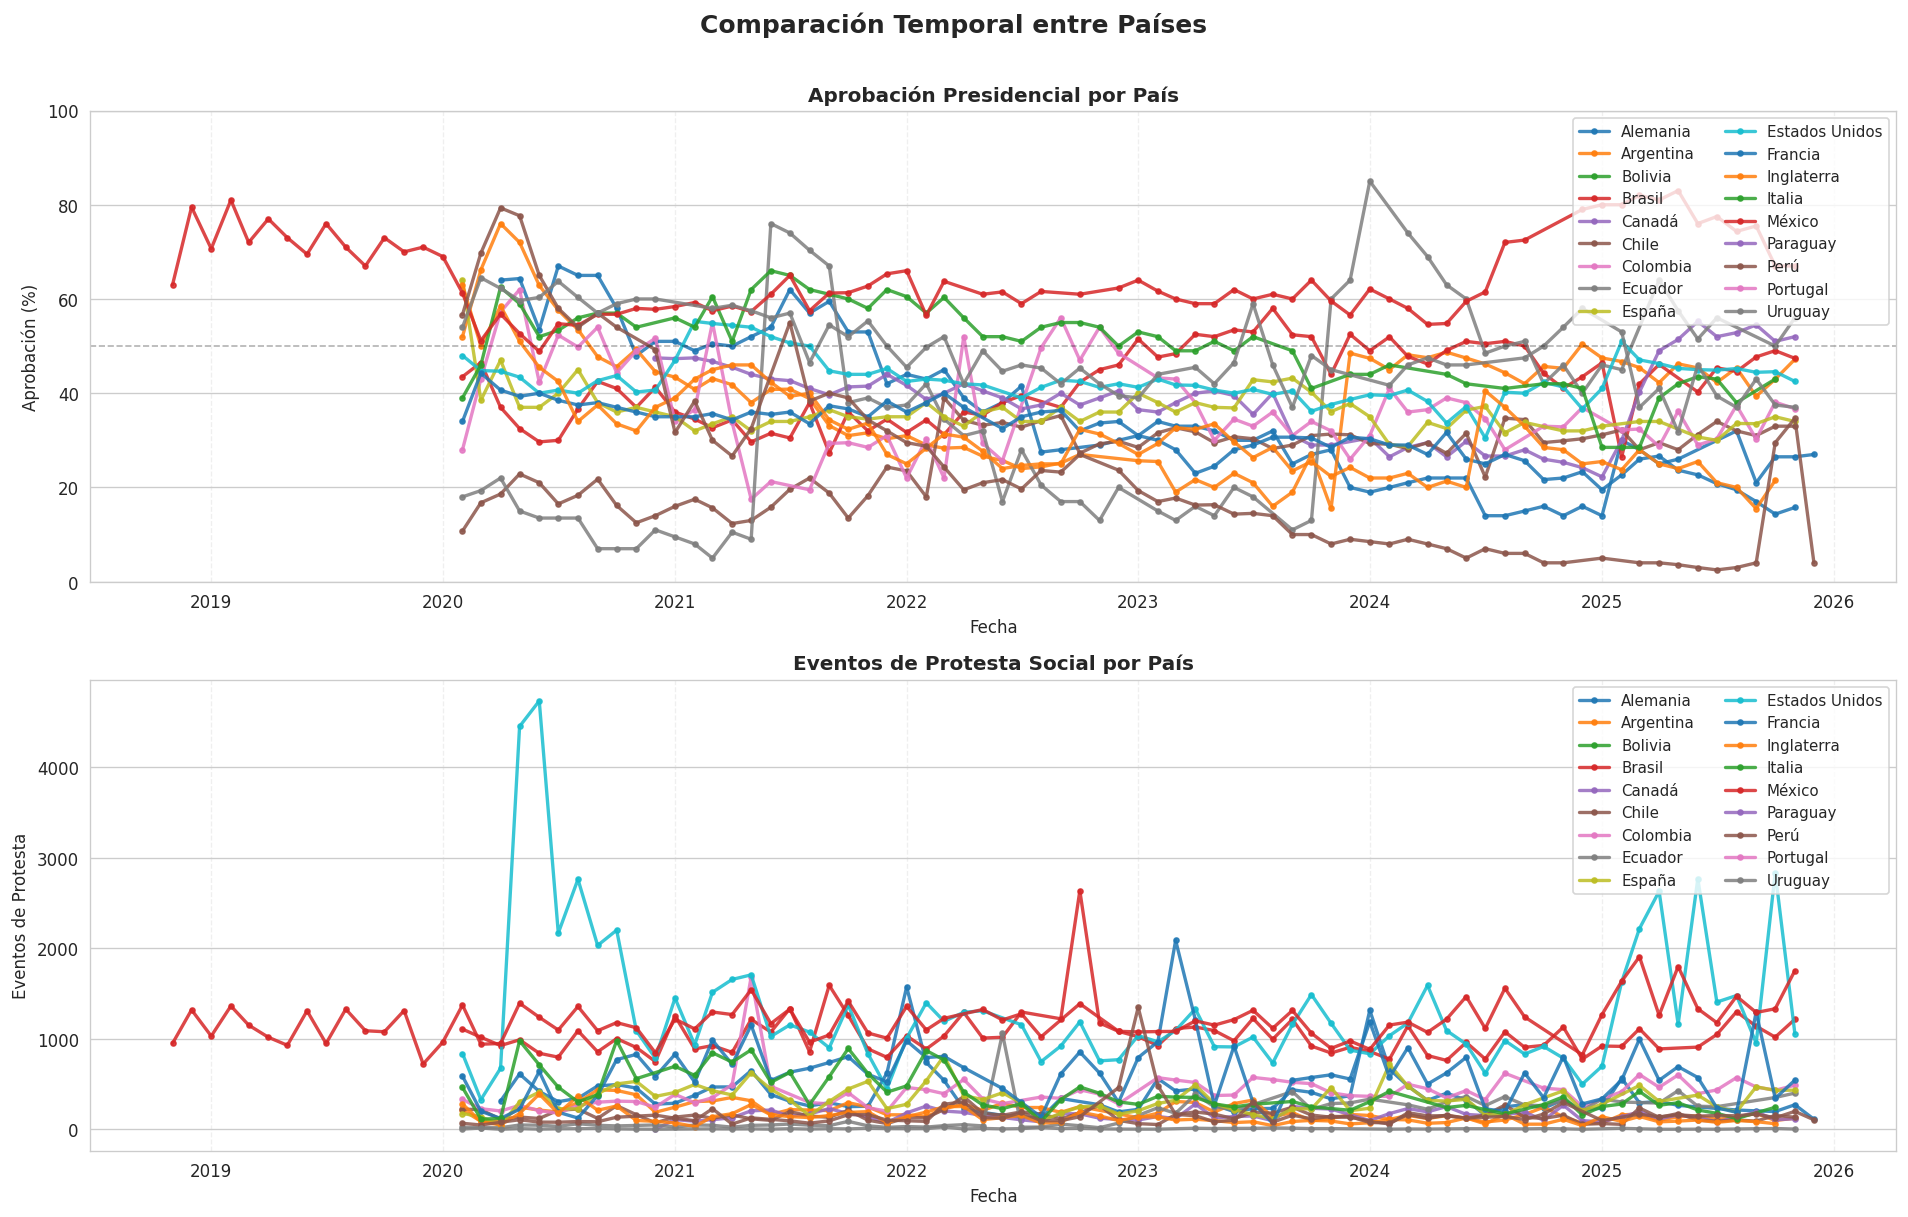

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)
colors = sns.color_palette(PALETTE, len(PAISES))

for i, pais in enumerate(PAISES):
    sub = df[df['País'] == pais].sort_values('Fecha').dropna(subset=['Fecha'])
    axes[0].plot(sub['Fecha'], sub['Aprobacion'],
                 color=colors[i], linewidth=2, label=pais, marker='o', markersize=3, alpha=0.85)
    axes[1].plot(sub['Fecha'], sub['Protestas'],
                 color=colors[i], linewidth=2, label=pais, marker='o', markersize=3, alpha=0.85)

axes[0].axhline(50, color='black', linestyle='--', alpha=0.3, linewidth=1)
axes[0].set_title('Aprobación Presidencial por País', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Aprobación (%)')
axes[0].set_ylim(0, 100)
axes[0].legend(loc='upper right', fontsize=9, ncol=2)

axes[1].set_title('Eventos de Protesta Social por País', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Eventos de Protesta')
axes[1].legend(loc='upper right', fontsize=9, ncol=2)

for ax in axes:
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.set_xlabel('Fecha')

fig.suptitle('Comparación Temporal entre Países', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Análisis de Outliers y Eventos Críticos

In [ ]:
# Función para detectar outliers con IQR
def detectar_outliers(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return (serie > Q3 + 1.5 * IQR) | (serie < Q1 - 1.5 * IQR)

# Calcular outliers
df['outlier_ps'] = df.groupby('País')['Protestas'].transform(detectar_outliers)
df['outlier_ap'] = df.groupby('País')['Aprobacion'].transform(detectar_outliers)

resumen_outliers = df.groupby('País').agg(
    Total_Meses=('Fecha', 'count'),
    Outliers_PS=('outlier_ps', 'sum'),
    Outliers_AP=('outlier_ap', 'sum')
).reset_index()
resumen_outliers['Pct_Outliers_PS'] = (resumen_outliers['Outliers_PS'] / resumen_outliers['Total_Meses'] * 100).round(1)
resumen_outliers['Pct_Outliers_AP'] = (resumen_outliers['Outliers_AP'] / resumen_outliers['Total_Meses'] * 100).round(1)
resumen_outliers = resumen_outliers.sort_values('Pct_Outliers_PS', ascending=False)

print(resumen_outliers.to_string(index=False))

          País  Total_Meses  Outliers_PS  Outliers_AP  Pct_Outliers_PS  Pct_Outliers_AP
          Perú           66            7            2             10.6              3.0
Estados Unidos           69            6            6              8.7              8.7
    Inglaterra           69            4            2              5.8              2.9
        México           80            3            0              3.8              0.0
        Italia           61            2            0              3.3              0.0
       Uruguay           62            2            0              3.2              0.0
      Alemania           66            2            0              3.0              0.0
        Brasil           68            2            0              2.9              0.0
     Argentina           68            2            0              2.9              0.0
       Ecuador           64            1            0              1.6              0.0
      Colombia           65     

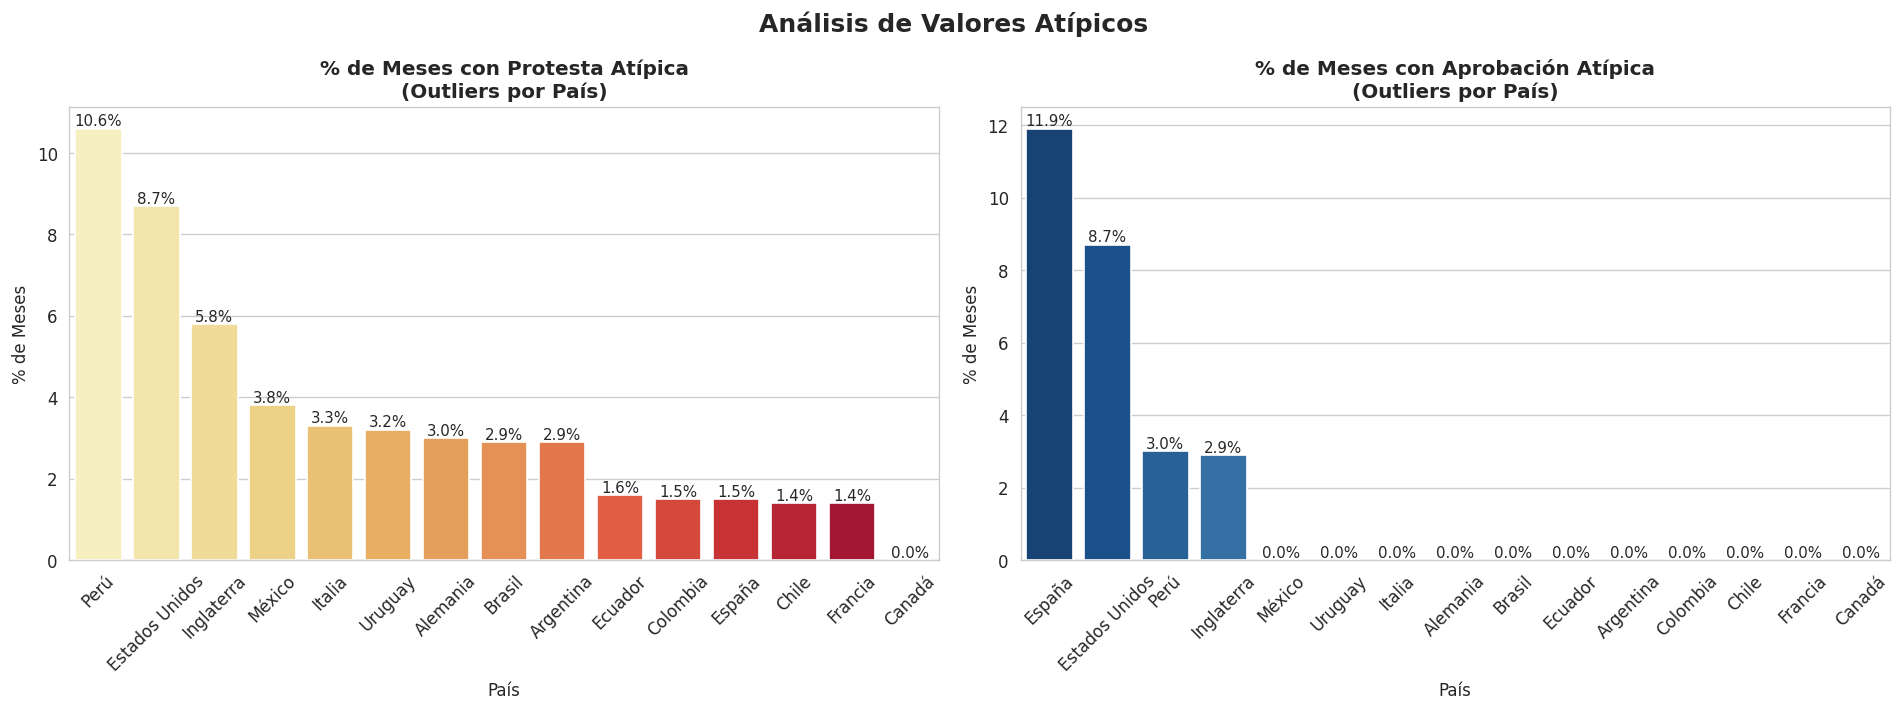

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Outliers Protesta Social
sns.barplot(data=resumen_outliers, x='País', y='Pct_Outliers_PS',
            palette='YlOrRd', ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)
axes[0].set_title('% de Meses con Protesta Atípica\n(Outliers por País)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% de Meses')
axes[0].tick_params(axis='x', rotation=45)

# Outliers Aprobación Presidencial
orden_ap = resumen_outliers.sort_values('Pct_Outliers_AP', ascending=False)
sns.barplot(data=orden_ap, x='País', y='Pct_Outliers_AP',
            palette='Blues_r', ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='bottom', fontsize=9)
axes[1].set_title('% de Meses con Aprobación Atípica\n(Outliers por País)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% de Meses')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Análisis de Valores Atípicos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 meses con más protestas (eventos críticos)
top_protestas = df.nlargest(10, 'Protestas')[['País', 'Mes', 'Año', 'Protestas', 'Aprobacion']]
print('=== Top 10 Meses con Mayor Protesta Social ===')
print(top_protestas.to_string(index=False))

=== Top 10 Meses con Mayor Protesta Social ===
          País     Mes  Año  Protestas  Aprobacion
Estados Unidos   Junio 2020       4736   40.000000
Estados Unidos    Mayo 2020       4454   43.400000
Estados Unidos Octubre 2025       2836   44.566667
Estados Unidos   Junio 2025       2770   45.000000
Estados Unidos  Agosto 2020       2764   40.000000
        Brasil Octubre 2022       2638   42.333333
Estados Unidos   Abril 2025       2631   46.275000
Estados Unidos   Marzo 2025       2219   47.075000
Estados Unidos Octubre 2020       2202   43.750000
Estados Unidos   Julio 2020       2170   40.666667


---
## 6. Análisis de Correlación entre Aprobación Presidencial y Protesta Social
### 6.1 Correlación Global

In [ ]:
# --- Correlaciones globales ---
df_corr = df[['Aprobacion', 'Protestas']].dropna()
r_pearson, p_pearson = pearsonr(df_corr['Aprobacion'], df_corr['Protestas'])
r_spearman, p_spearman = spearmanr(df_corr['Aprobacion'], df_corr['Protestas'])

print('=== Correlación Global Aprobación vs Protestas ===')
print(f'  Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.4f})')
print(f'  Spearman ρ = {r_spearman:.4f}  (p = {p_spearman:.4f})')
if abs(r_pearson) < 0.2:
    print('  ➜ Correlación muy débil')
elif abs(r_pearson) < 0.4:
    print('  ➜ Correlación débil')
elif abs(r_pearson) < 0.6:
    print('  ➜ Correlación moderada')
else:
    print('  ➜ Correlación fuerte')

=== Correlación Global Aprobación vs Protestas ===
  Pearson  r = 0.3247  (p = 0.0000)
  Spearman ρ = 0.2842  (p = 0.0000)
  ➜ Correlación débil


In [ ]:
# --- Correlaciones globales ---
df_corr = df[['Aprobacion', 'Tasa_Protestas']].dropna()
r_pearson, p_pearson = pearsonr(df_corr['Aprobacion'], df_corr['Tasa_Protestas'])
r_spearman, p_spearman = spearmanr(df_corr['Aprobacion'], df_corr['Tasa_Protestas'])

print('=== Correlación Global Aprobación vs Tasa de Protestas ===')
print(f'  Pearson  r = {r_pearson:.4f}  (p = {p_pearson:.4f})')
print(f'  Spearman ρ = {r_spearman:.4f}  (p = {p_spearman:.4f})')
if abs(r_pearson) < 0.2:
    print('  ➜ Correlación muy débil')
elif abs(r_pearson) < 0.4:
    print('  ➜ Correlación débil')
elif abs(r_pearson) < 0.6:
    print('  ➜ Correlación moderada')
else:
    print('  ➜ Correlación fuerte')

=== Correlación Global Aprobación vs Tasa de Protestas ===
  Pearson  r = 0.0884  (p = 0.0051)
  Spearman ρ = 0.0947  (p = 0.0027)
  ➜ Correlación muy débil


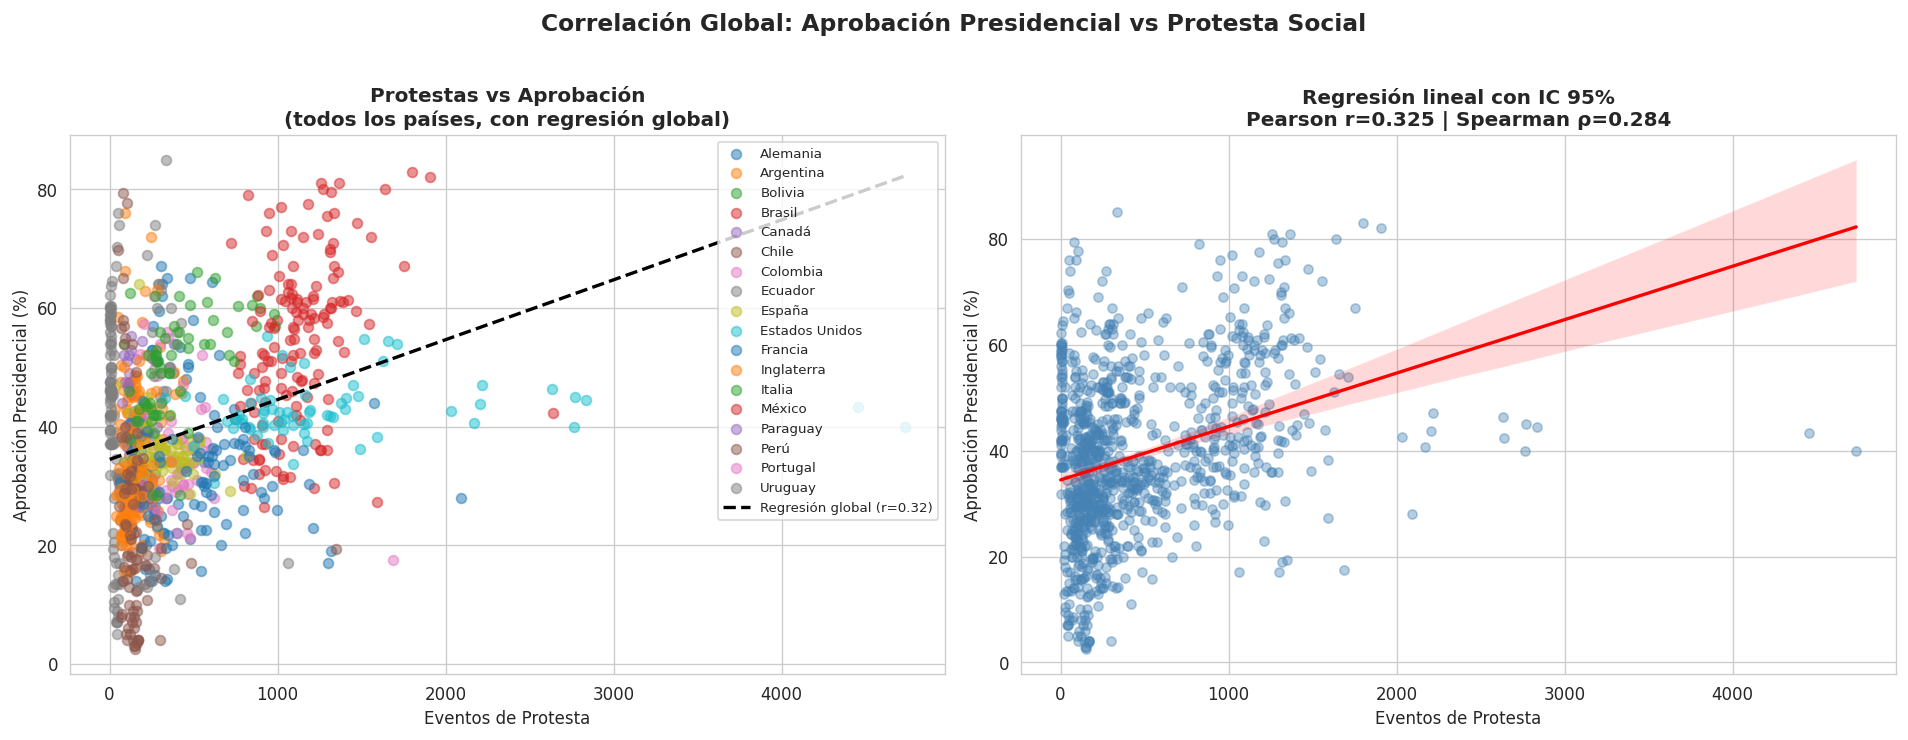

In [ ]:
# --- Scatterplot global con regresión ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por país con colores
colors = sns.color_palette(PALETTE, len(PAISES))
for i, pais in enumerate(PAISES):
    sub = df[df['País'] == pais].dropna(subset=['Aprobacion', 'Protestas'])
    axes[0].scatter(sub['Protestas'], sub['Aprobacion'],
                    color=colors[i], alpha=0.5, s=35, label=pais)

# Línea de regresión global
x_fit = df['Protestas'].dropna()
y_fit = df['Aprobacion'].dropna()
idx = x_fit.index.intersection(y_fit.index)
m, b, _, _, _ = stats.linregress(x_fit[idx], y_fit[idx])
x_line = np.linspace(x_fit[idx].min(), x_fit[idx].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='black', linewidth=2,
             linestyle='--', label=f'Regresión global (r={r_pearson:.2f})')

axes[0].set_title('Protestas vs Aprobación\n(todos los países, con regresión global)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Eventos de Protesta')
axes[0].set_ylabel('Aprobación Presidencial (%)')
axes[0].legend(fontsize=8, loc='upper right')

# Regresión con intervalo de confianza (seaborn)
sns.regplot(data=df, x='Protestas', y='Aprobacion',
            scatter_kws={'alpha': 0.4, 'color': 'steelblue', 's': 30},
            line_kws={'color': 'red', 'linewidth': 2},
            ci=95, ax=axes[1])
axes[1].set_title(f'Regresión lineal con IC 95%\nPearson r={r_pearson:.3f} | Spearman ρ={r_spearman:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Eventos de Protesta')
axes[1].set_ylabel('Aprobación Presidencial (%)')

plt.suptitle('Correlación Global: Aprobación Presidencial vs Protesta Social',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

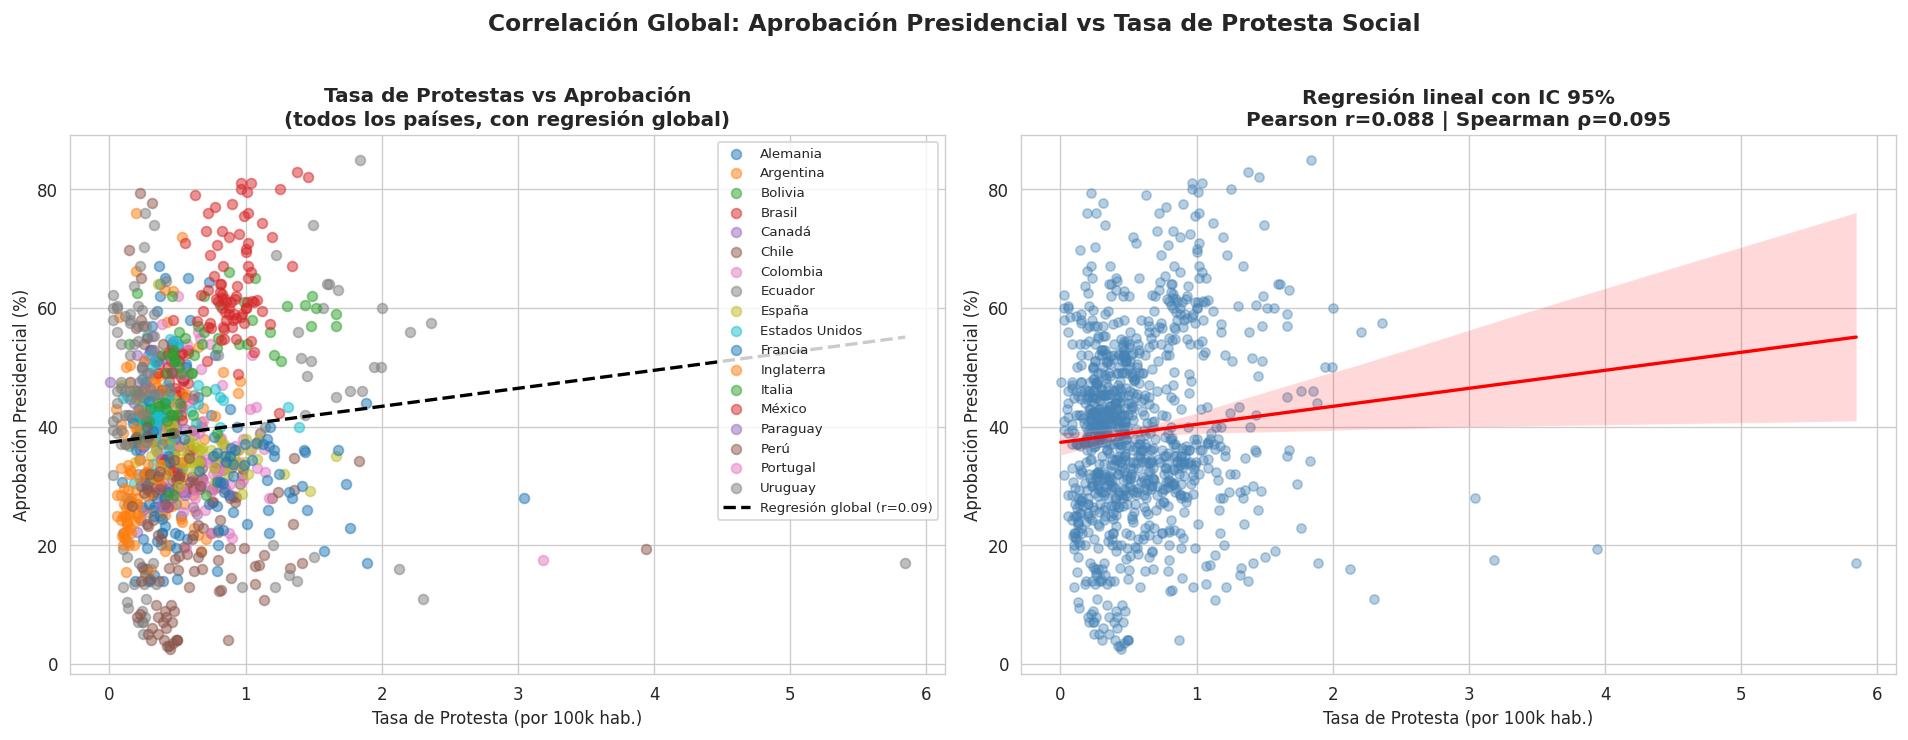

In [ ]:
# --- Scatterplot global con regresión ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por país con colores
colors = sns.color_palette(PALETTE, len(PAISES))
for i, pais in enumerate(PAISES):
    sub = df[df['País'] == pais].dropna(subset=['Aprobacion', 'Tasa_Protestas'])
    axes[0].scatter(sub['Tasa_Protestas'], sub['Aprobacion'],
                    color=colors[i], alpha=0.5, s=35, label=pais)

# Línea de regresión global
x_fit = df['Tasa_Protestas'].dropna()
y_fit = df['Aprobacion'].dropna()
idx = x_fit.index.intersection(y_fit.index)
m, b, _, _, _ = stats.linregress(x_fit[idx], y_fit[idx])
x_line = np.linspace(x_fit[idx].min(), x_fit[idx].max(), 100)
axes[0].plot(x_line, m * x_line + b, color='black', linewidth=2,
             linestyle='--', label=f'Regresión global (r={r_pearson:.2f})')

axes[0].set_title('Tasa de Protestas vs Aprobación\n(todos los países, con regresión global)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tasa de Protesta (por 100k hab.)')
axes[0].set_ylabel('Aprobación Presidencial (%)')
axes[0].legend(fontsize=8, loc='upper right')

# Regresión con intervalo de confianza (seaborn)
sns.regplot(data=df, x='Tasa_Protestas', y='Aprobacion',
            scatter_kws={'alpha': 0.4, 'color': 'steelblue', 's': 30},
            line_kws={'color': 'red', 'linewidth': 2},
            ci=95, ax=axes[1])
axes[1].set_title(f'Regresión lineal con IC 95%\nPearson r={r_pearson:.3f} | Spearman ρ={r_spearman:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tasa de Protesta (por 100k hab.)')
axes[1].set_ylabel('Aprobación Presidencial (%)')

plt.suptitle('Correlación Global: Aprobación Presidencial vs Tasa de Protesta Social',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Correlación por País

In [ ]:
# --- Correlación individual por país ---
corr_por_pais = []
for pais in PAISES:
    sub = df[df['País'] == pais][['Aprobacion', 'Protestas']].dropna()
    if len(sub) < 5:
        continue
    r_p, p_p = pearsonr(sub['Aprobacion'], sub['Protestas'])
    r_s, p_s = spearmanr(sub['Aprobacion'], sub['Protestas'])
    corr_por_pais.append({
        'País': pais,
        'n': len(sub),
        'Pearson_r': round(r_p, 4),
        'Pearson_p': round(p_p, 4),
        'Spearman_rho': round(r_s, 4),
        'Spearman_p': round(p_s, 4),
        'Significativa': '✅' if p_p < 0.05 else '❌'
    })

df_corr_pais = pd.DataFrame(corr_por_pais).sort_values('Pearson_r')
print('=== Correlación Aprobación vs Protestas por País ===')
df_corr_pais

=== Correlación Aprobación vs Protestas por País ===


,País,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Significativa
7,España,67,-0.3866,0.0012,-0.3505,0.0036,✅
5,Colombia,65,-0.3609,0.0031,-0.2613,0.0355,✅
3,Canadá,59,-0.2919,0.0249,-0.2371,0.0706,✅
1,Argentina,68,-0.1787,0.1448,-0.2392,0.0495,❌
13,Perú,66,-0.1570,0.2081,-0.3798,0.0017,❌
2,Brasil,68,-0.0669,0.5876,-0.0146,0.9059,❌
9,Francia,69,-0.0469,0.7018,0.0009,0.9941,❌
4,Chile,70,-0.0332,0.7850,-0.0637,0.6005,❌
14,Uruguay,62,0.0480,0.7111,0.0531,0.6819,❌
8,Estados Unidos,69,0.1215,0.3201,0.2522,0.0366,❌


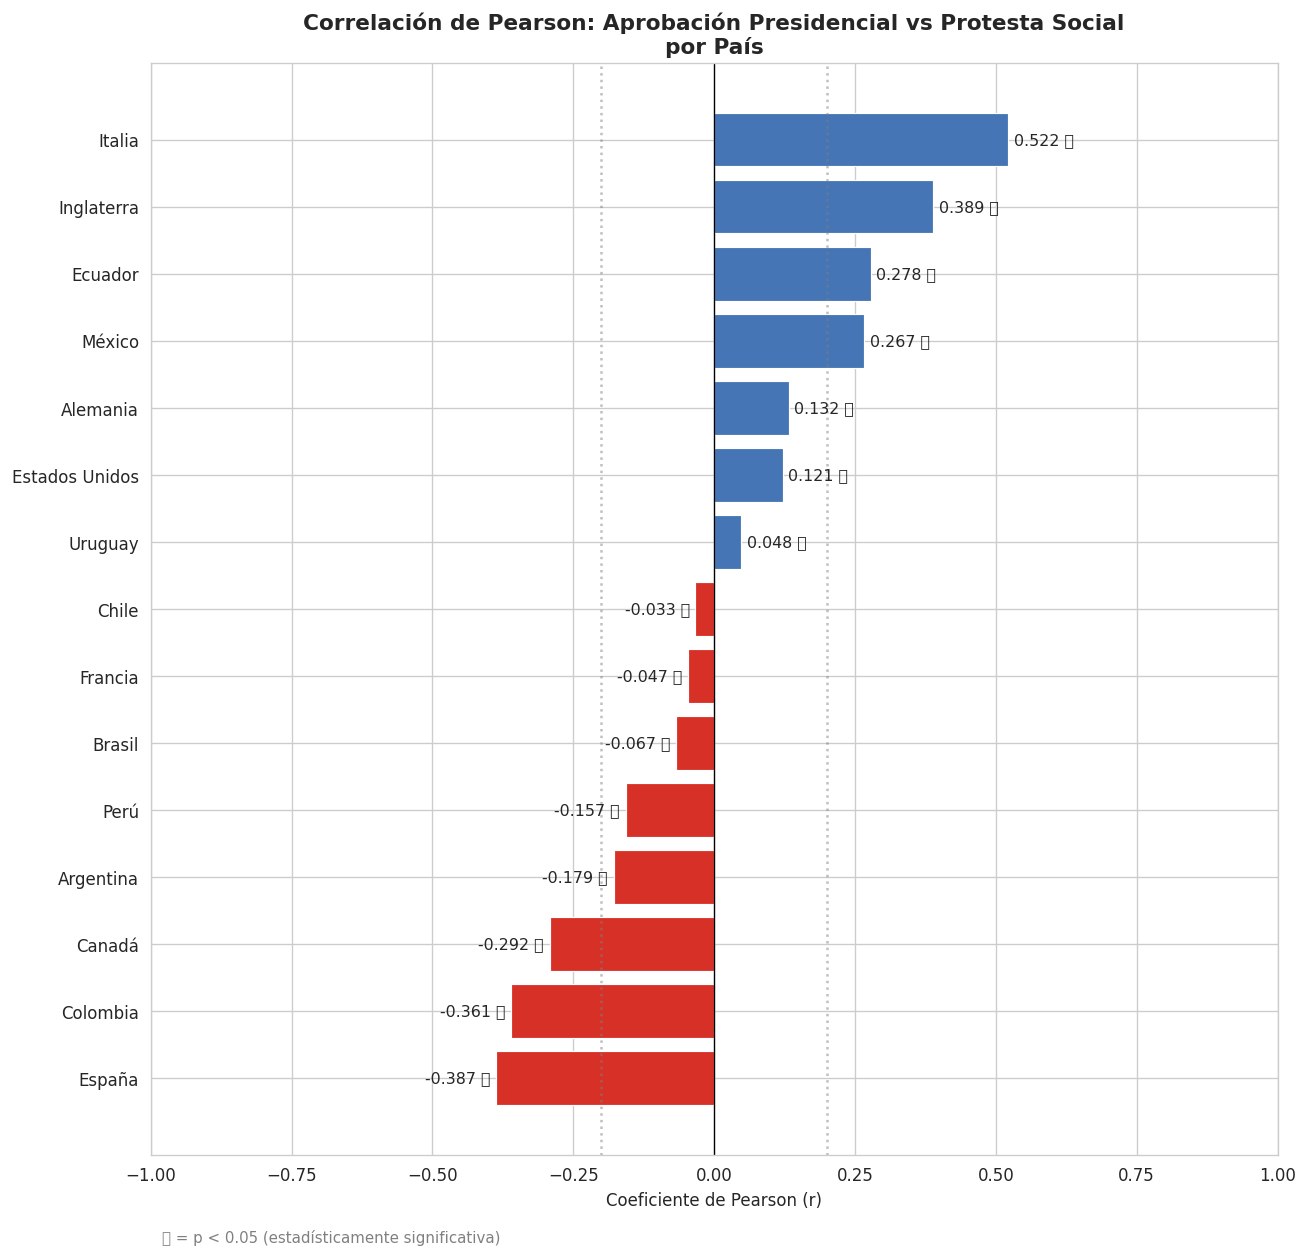

In [ ]:
# --- Gráfico de correlaciones por país ---
fig, ax = plt.subplots(figsize=(11, max(5, len(df_corr_pais) * 0.7)))

colors_bar = ['#d73027' if v < 0 else '#4575b4' for v in df_corr_pais['Pearson_r']]
bars = ax.barh(df_corr_pais['País'], df_corr_pais['Pearson_r'],
               color=colors_bar, edgecolor='white', linewidth=0.7)

for bar, r, sig in zip(bars, df_corr_pais['Pearson_r'], df_corr_pais['Significativa']):
    xpos = bar.get_width() + (0.01 if bar.get_width() >= 0 else -0.01)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{r:.3f} {sig}', va='center', fontsize=9.5,
            ha='left' if bar.get_width() >= 0 else 'right')

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(-0.2, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0.2, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Correlación de Pearson: Aprobación Presidencial vs Protesta Social\npor País',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de Pearson (r)')
ax.set_xlim(-1, 1)
ax.text(0.01, -0.08, '✅ = p < 0.05 (estadísticamente significativa)',
        transform=ax.transAxes, fontsize=9, color='gray')
plt.tight_layout()
plt.show()

In [ ]:
# --- Correlación individual por país (Tasa de Protestas) ---
corr_por_pais_tasa = []
for pais in PAISES:
    sub = df[df['País'] == pais][['Aprobacion', 'Tasa_Protestas']].dropna()
    if len(sub) < 5:
        continue
    r_p, p_p = pearsonr(sub['Aprobacion'], sub['Tasa_Protestas'])
    r_s, p_s = spearmanr(sub['Aprobacion'], sub['Tasa_Protestas'])
    corr_por_pais_tasa.append({
        'País': pais,
        'n': len(sub),
        'Pearson_r': round(r_p, 4),
        'Pearson_p': round(p_p, 4),
        'Spearman_rho': round(r_s, 4),
        'Spearman_p': round(p_s, 4),
        'Significativa': '✅' if p_p < 0.05 else '❌'
    })

df_corr_pais_tasa = pd.DataFrame(corr_por_pais_tasa).sort_values('Pearson_r')
print('=== Correlación Aprobación vs Tasa de Protestas por País ===')
df_corr_pais_tasa

=== Correlación Aprobación vs Tasa de Protestas por País ===


,País,n,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,Significativa
7,España,67,-0.3866,0.0012,-0.3505,0.0036,✅
5,Colombia,65,-0.3609,0.0031,-0.2613,0.0355,✅
3,Canadá,59,-0.2919,0.0249,-0.2371,0.0706,✅
1,Argentina,68,-0.1787,0.1448,-0.2392,0.0495,❌
13,Perú,66,-0.1570,0.2081,-0.3798,0.0017,❌
2,Brasil,68,-0.0669,0.5876,-0.0146,0.9059,❌
9,Francia,69,-0.0469,0.7018,0.0009,0.9941,❌
4,Chile,70,-0.0332,0.7850,-0.0637,0.6005,❌
14,Uruguay,62,0.0480,0.7111,0.0531,0.6819,❌
8,Estados Unidos,69,0.1215,0.3201,0.2522,0.0366,❌


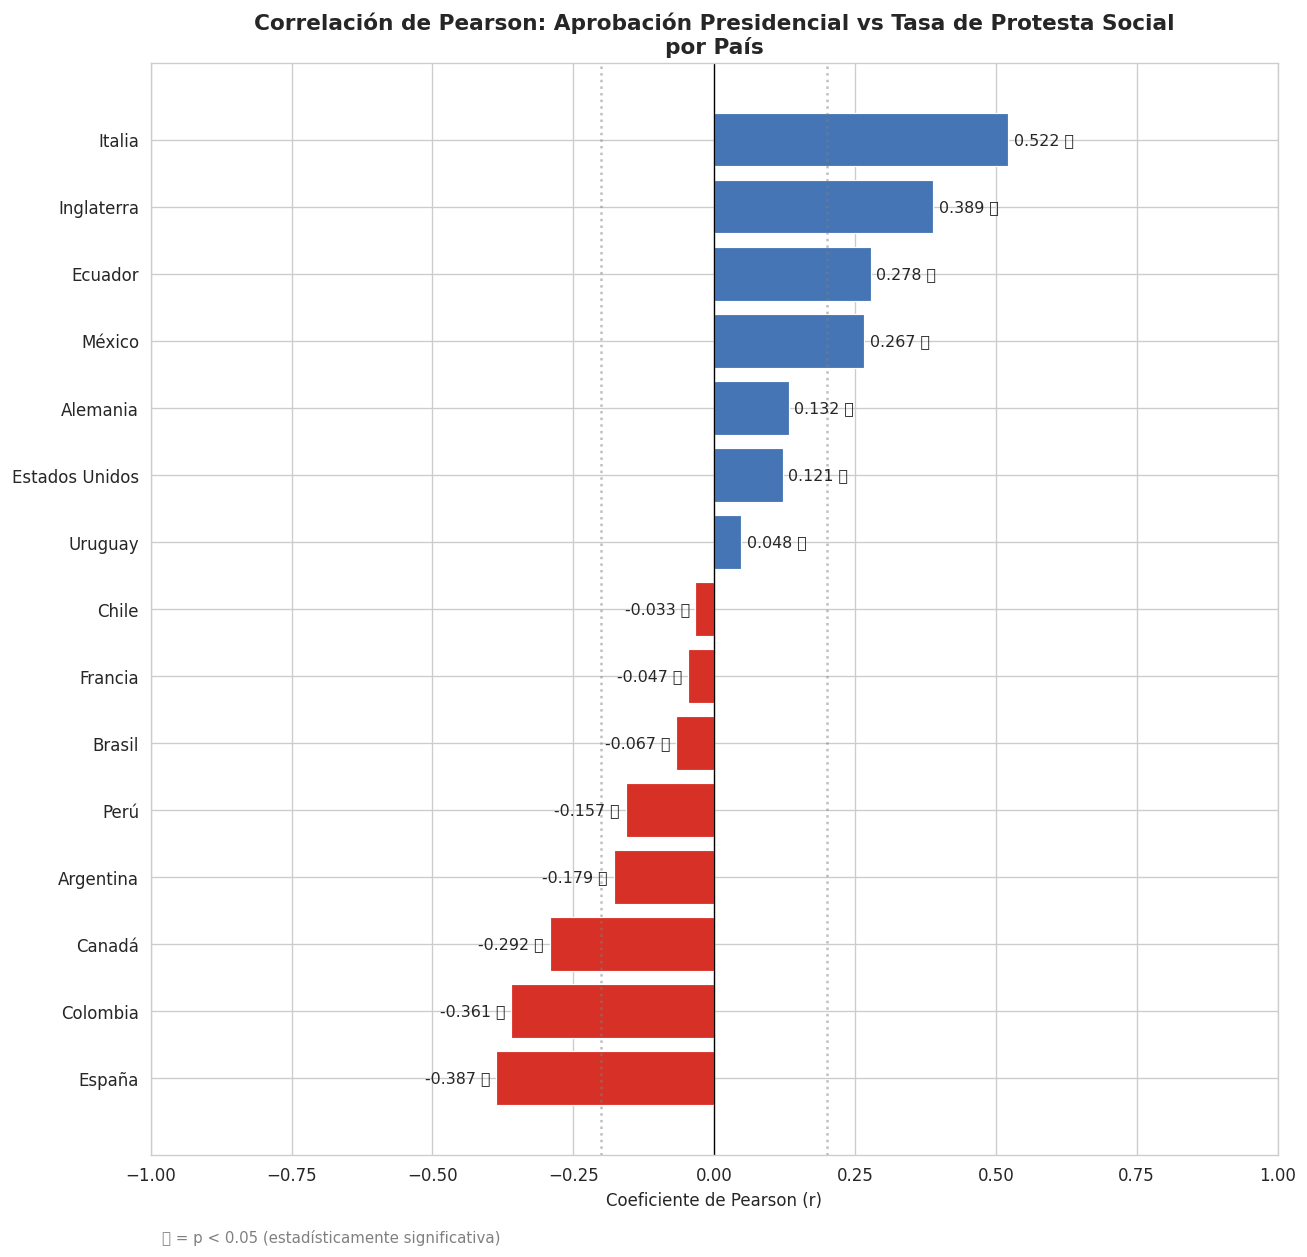

In [ ]:
# --- Gráfico de correlaciones por país (Tasa de Protestas) ---
fig, ax = plt.subplots(figsize=(11, max(5, len(df_corr_pais_tasa) * 0.7)))

colors_bar = ['#d73027' if v < 0 else '#4575b4' for v in df_corr_pais_tasa['Pearson_r']]
bars = ax.barh(df_corr_pais_tasa['País'], df_corr_pais_tasa['Pearson_r'],
               color=colors_bar, edgecolor='white', linewidth=0.7)

for bar, r, sig in zip(bars, df_corr_pais_tasa['Pearson_r'], df_corr_pais_tasa['Significativa']):
    xpos = bar.get_width() + (0.01 if bar.get_width() >= 0 else -0.01)
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{r:.3f} {sig}', va='center', fontsize=9.5,
            ha='left' if bar.get_width() >= 0 else 'right')

ax.axvline(0, color='black', linewidth=0.8)
ax.axvline(-0.2, color='gray', linestyle=':', alpha=0.5)
ax.axvline(0.2, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Correlación de Pearson: Aprobación Presidencial vs Tasa de Protesta Social\npor País',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coeficiente de Pearson (r)')
ax.set_xlim(-1, 1)
ax.text(0.01, -0.08, '✅ = p < 0.05 (estadísticamente significativa)',
        transform=ax.transAxes, fontsize=9, color='gray')
plt.tight_layout()
plt.show()

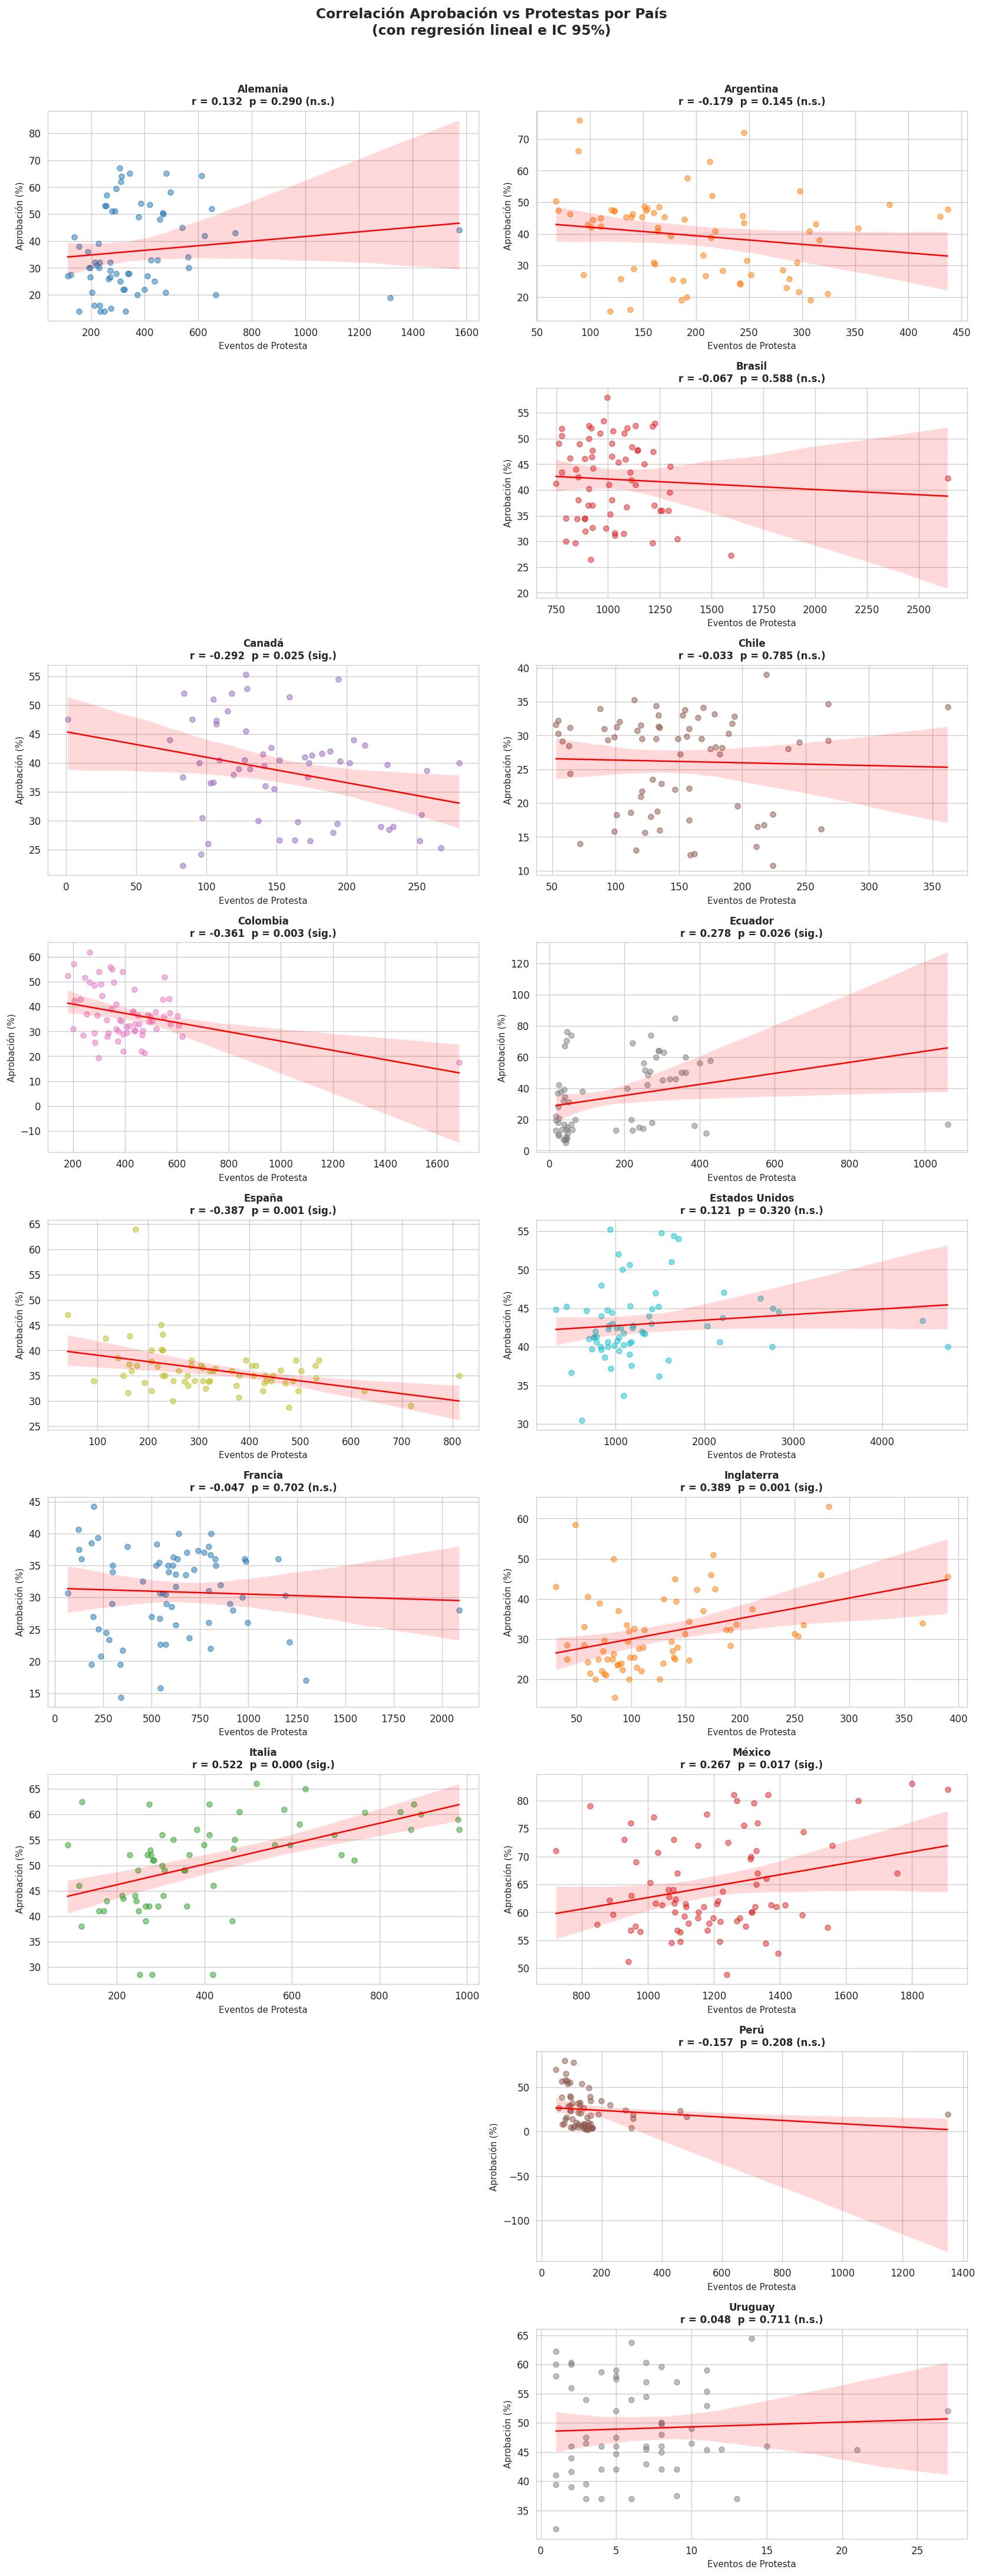

In [ ]:
# --- Scatterplot por país con regresión individual ---
n = len(PAISES)
ncols = 2
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 4))
axes_flat = axes.flatten() if n > 1 else [axes]

for i, pais in enumerate(PAISES):
    ax = axes_flat[i]
    sub = df[df['País'] == pais].dropna(subset=['Aprobacion', 'Protestas'])
    if len(sub) < 5:
        ax.set_visible(False)
        continue

    r_p, p_p = pearsonr(sub['Aprobacion'], sub['Protestas'])
    sns.regplot(data=sub, x='Protestas', y='Aprobacion',
                scatter_kws={'alpha': 0.5, 's': 30, 'color': colors[i % len(colors)]},
                line_kws={'color': 'red', 'linewidth': 1.5},
                ci=95, ax=ax)

    sig_str = '(sig.)' if p_p < 0.05 else '(n.s.)'
    ax.set_title(f'{pais}\nr = {r_p:.3f}  p = {p_p:.3f} {sig_str}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Eventos de Protesta', fontsize=9)
    ax.set_ylabel('Aprobación (%)', fontsize=9)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle('Correlación Aprobación vs Protestas por País\n(con regresión lineal e IC 95%)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 6.3 Correlación con Rezago Temporal (Lag)

Un aumento en la protesta social puede no impactar la aprobación presidencial de forma inmediata. Exploramos correlaciones con rezagos de 1 a 6 meses.

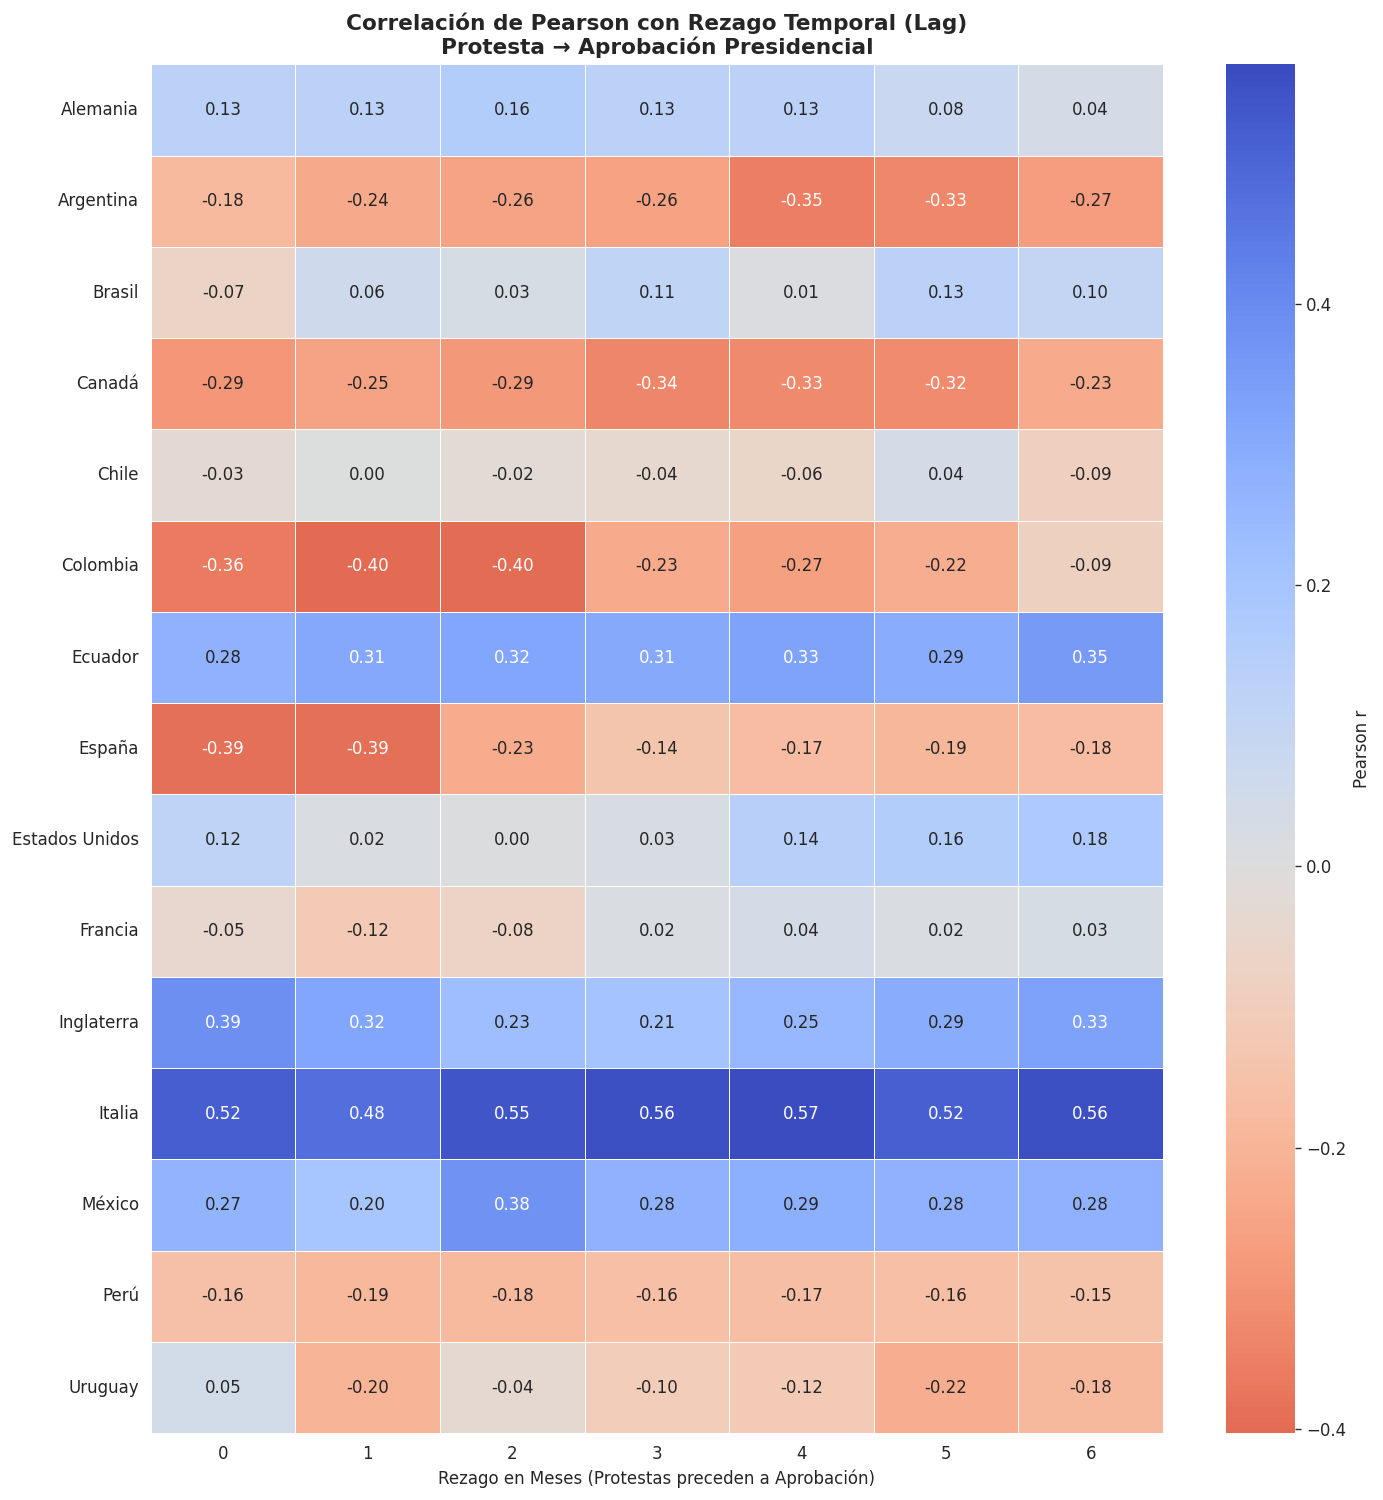

In [ ]:
# Correlación con lag (rezago) por país
lags = list(range(0, 7))  # 0 a 6 meses
lag_results = []

for pais in PAISES:
    sub = df[df['País'] == pais].sort_values('Fecha').dropna(subset=['Aprobacion', 'Protestas'])
    if len(sub) < 10:
        continue
    for lag in lags:
        ap = sub['Aprobacion'].values[lag:]
        ps = sub['Protestas'].values[:len(sub) - lag] if lag > 0 else sub['Protestas'].values
        if len(ap) < 5:
            continue
        r, p = pearsonr(ap, ps)
        lag_results.append({'País': pais, 'Lag (meses)': lag, 'Pearson_r': r, 'p_valor': p})

df_lag = pd.DataFrame(lag_results)

# Heatmap de correlaciones por lag y país
pivot_lag = df_lag.pivot(index='País', columns='Lag (meses)', values='Pearson_r').round(3)

fig, ax = plt.subplots(figsize=(12, max(5, len(PAISES) * 0.7)))
sns.heatmap(pivot_lag, annot=True, fmt='.2f', cmap='coolwarm_r',
            center=0, linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlación de Pearson con Rezago Temporal (Lag)\nProtesta → Aprobación Presidencial',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Rezago en Meses (Protestas preceden a Aprobación)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Mejor lag por país
mejor_lag = df_lag.loc[df_lag.groupby('País')['Pearson_r'].apply(lambda x: x.abs().idxmax())]
mejor_lag = mejor_lag.sort_values('Pearson_r')
print('=== Lag con Mayor Correlación Absoluta por País ===')
print(mejor_lag[['País', 'Lag (meses)', 'Pearson_r', 'p_valor']].to_string(index=False))

=== Lag con Mayor Correlación Absoluta por País ===
          País  Lag (meses)  Pearson_r  p_valor
      Colombia            1  -0.402535 0.000975
        España            1  -0.390908 0.001173
     Argentina            4  -0.349638 0.004627
        Canadá            3  -0.334742 0.011679
       Uruguay            5  -0.224462 0.093230
          Perú            1  -0.187038 0.135728
       Francia            1  -0.114844 0.351046
         Chile            6  -0.090747 0.475756
        Brasil            5   0.130212 0.309073
      Alemania            2   0.156822 0.215893
Estados Unidos            6   0.181884 0.153672
       Ecuador            6   0.351793 0.006769
        México            2   0.377150 0.000665
    Inglaterra            0   0.388756 0.000963
        Italia            4   0.570347 0.000004


---
## 7. Resumen Final y Conclusiones

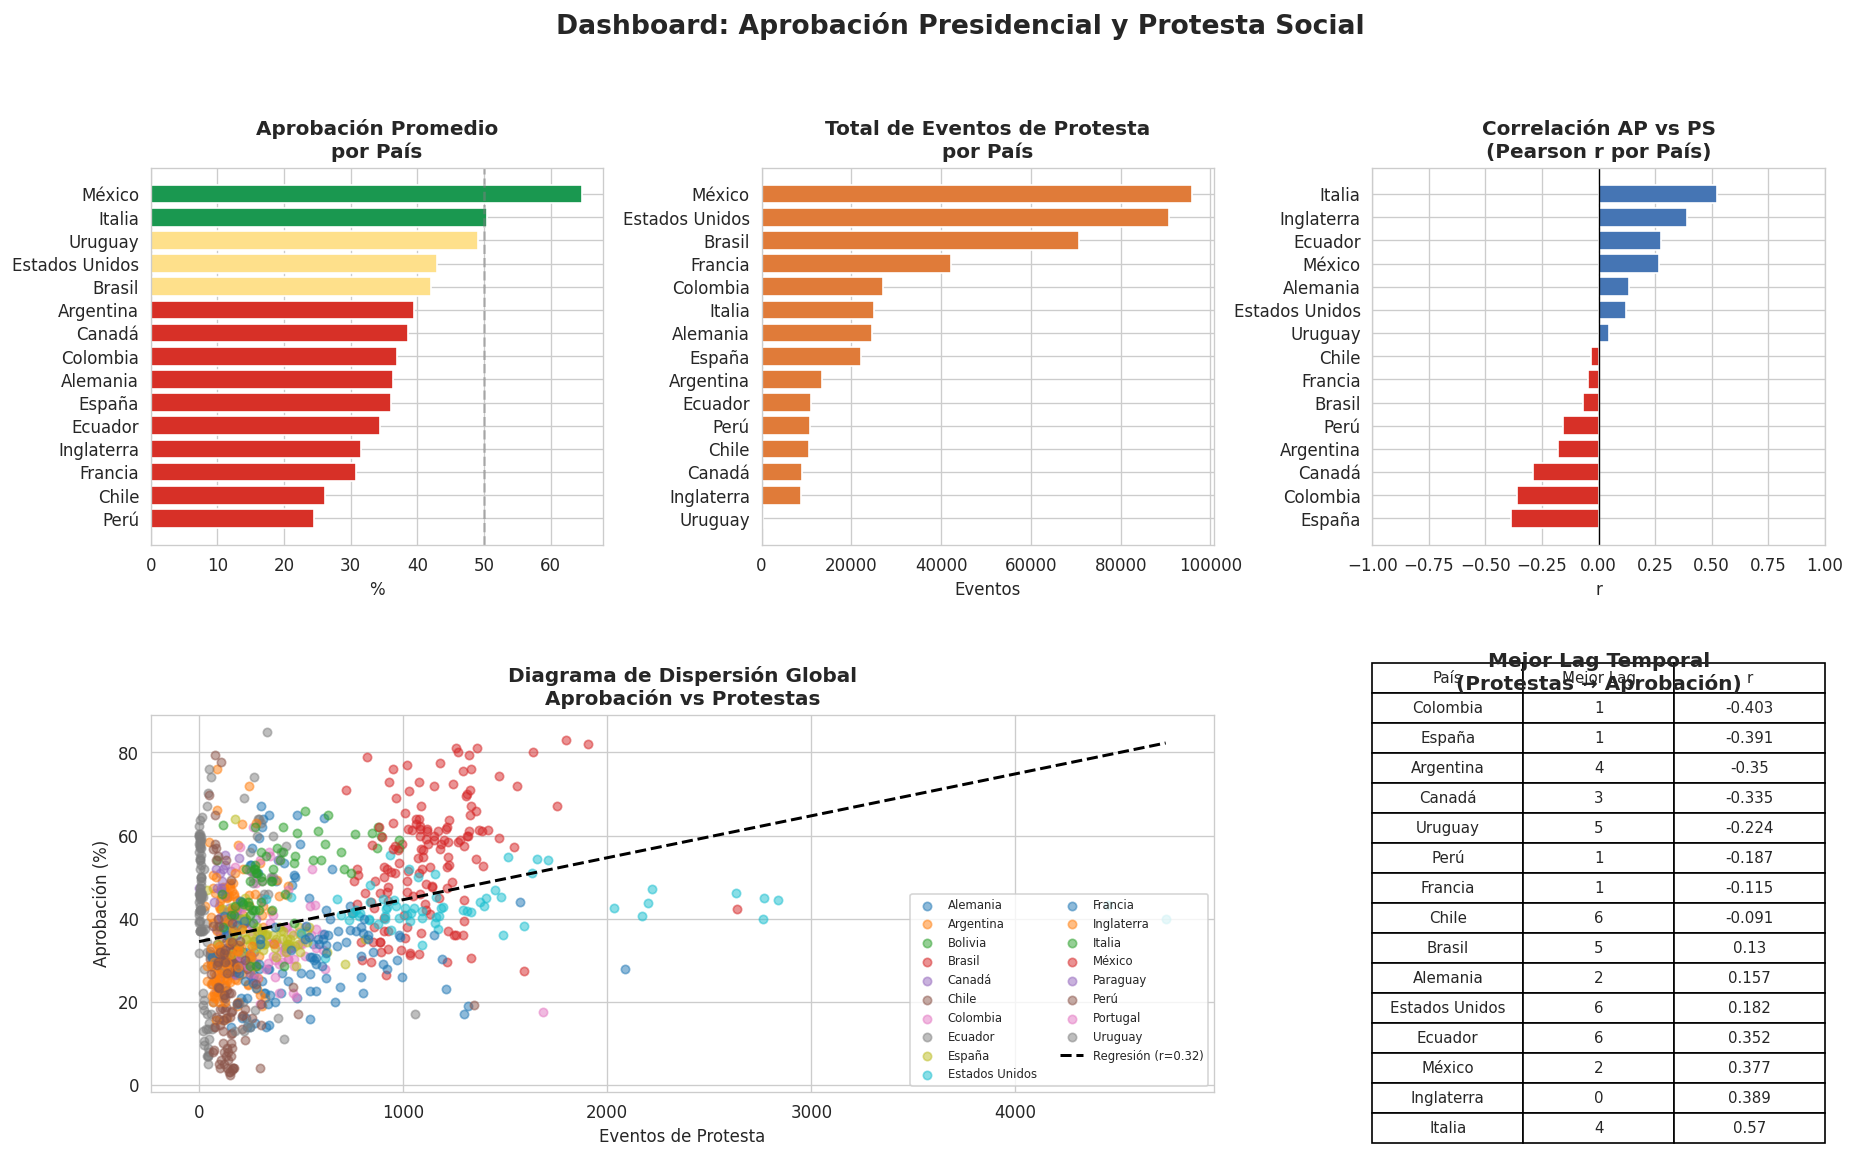

✅ Dashboard guardado como dashboard_ap_ps.png


In [ ]:
# --- Dashboard de resumen ---
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. AP Promedio por País
ax1 = fig.add_subplot(gs[0, 0])
ap_prom = df.groupby('País')['Aprobacion'].mean().sort_values()
ax1.barh(ap_prom.index, ap_prom.values,
         color=['#d73027' if v < 40 else '#fee08b' if v < 50 else '#1a9850' for v in ap_prom.values])
ax1.axvline(50, color='gray', linestyle='--', alpha=0.5)
ax1.set_title('Aprobación Promedio\npor País', fontweight='bold')
ax1.set_xlabel('%')

# 2. Protestas Totales
ax2 = fig.add_subplot(gs[0, 1])
ps_tot = df.groupby('País')['Protestas'].sum().sort_values()
ax2.barh(ps_tot.index, ps_tot.values, color='#e07b39')
ax2.set_title('Total de Eventos de Protesta\npor País', fontweight='bold')
ax2.set_xlabel('Eventos')

# 3. Correlación por País
ax3 = fig.add_subplot(gs[0, 2])
df_cp = df_corr_pais.sort_values('Pearson_r')
c3 = ['#d73027' if v < 0 else '#4575b4' for v in df_cp['Pearson_r']]
ax3.barh(df_cp['País'], df_cp['Pearson_r'], color=c3)
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_title('Correlación AP vs PS\n(Pearson r por País)', fontweight='bold')
ax3.set_xlabel('r')
ax3.set_xlim(-1, 1)

# 4. Scatter global
ax4 = fig.add_subplot(gs[1, 0:2])
colors_s = sns.color_palette(PALETTE, len(PAISES))
for i, pais in enumerate(PAISES):
    sub = df[df['País'] == pais].dropna(subset=['Aprobacion', 'Protestas'])
    ax4.scatter(sub['Protestas'], sub['Aprobacion'], color=colors_s[i], alpha=0.5, s=25, label=pais)
x_l = np.linspace(df['Protestas'].min(), df['Protestas'].max(), 100)
ax4.plot(x_l, m * x_l + b, 'k--', linewidth=1.8, label=f'Regresión (r={r_pearson:.2f})')
ax4.set_title('Diagrama de Dispersión Global\nAprobación vs Protestas', fontweight='bold')
ax4.set_xlabel('Eventos de Protesta')
ax4.set_ylabel('Aprobación (%)')
ax4.legend(fontsize=7, ncol=2)

# 5. Tabla de correlaciones con lag
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
tabla = mejor_lag[['País', 'Lag (meses)', 'Pearson_r']].copy()
tabla['Pearson_r'] = tabla['Pearson_r'].round(3)
t = ax5.table(cellText=tabla.values,
              colLabels=['País', 'Mejor Lag', 'r'],
              cellLoc='center', loc='center')
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1, 1.5)
ax5.set_title('Mejor Lag Temporal\n(Protestas → Aprobación)', fontweight='bold', pad=15)

fig.suptitle('Dashboard: Aprobación Presidencial y Protesta Social',
             fontsize=16, fontweight='bold', y=1.01)
plt.savefig('dashboard_ap_ps.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Dashboard guardado como dashboard_ap_ps.png')

In [ ]:
# --- Conclusiones automáticas ---
print('=' * 60)
print('  RESUMEN EJECUTIVO DEL ANÁLISIS')
print('=' * 60)

print(f'\n📌 Países analizados: {len(PAISES)}')
print(f'   {PAISES}')

print(f'\n📊 Aprobación Presidencial:')
top_ap = resumen['AP_media'].idxmax()
bot_ap = resumen['AP_media'].idxmin()
print(f'   Mayor promedio: {top_ap} ({resumen.loc[top_ap, "AP_media"]:.1f}%)')
print(f'   Menor promedio: {bot_ap} ({resumen.loc[bot_ap, "AP_media"]:.1f}%)')
more_vol = df.groupby('País')['Aprobacion'].std().idxmax()
print(f'   Más volátil: {more_vol} (σ={df.groupby("País")["Aprobacion"].std().max():.1f}%)')

print(f'\n📢 Protesta Social:')
top_ps = resumen['PS_total'].idxmax()
bot_ps = resumen['PS_total'].idxmin()
print(f'   Mayor total histórico: {top_ps} ({int(resumen.loc[top_ps, "PS_total"]):,} eventos)')
print(f'   Menor total histórico: {bot_ps} ({int(resumen.loc[bot_ps, "PS_total"]):,} eventos)')

print(f'\n🔗 Correlación global (AP vs PS):')
print(f'   Pearson r = {r_pearson:.4f}  (p = {p_pearson:.4f})')
print(f'   Spearman ρ = {r_spearman:.4f}  (p = {p_spearman:.4f})')

sig_paises = df_corr_pais[df_corr_pais['Pearson_p'] < 0.05]
print(f'\n   Países con correlación significativa (p<0.05):')
if len(sig_paises) > 0:
    for _, row in sig_paises.iterrows():
        dir_corr = 'negativa' if row['Pearson_r'] < 0 else 'positiva'
        print(f'     • {row["País"]}: r={row["Pearson_r"]:.3f} ({dir_corr})')
else:
    print('     Ninguno alcanzó significancia estadística.')
print('=' * 60)

  RESUMEN EJECUTIVO DEL ANÁLISIS

📌 Países analizados: 18
   ['Alemania', 'Argentina', 'Bolivia', 'Brasil', 'Canadá', 'Chile', 'Colombia', 'Ecuador', 'España', 'Estados Unidos', 'Francia', 'Inglaterra', 'Italia', 'México', 'Paraguay', 'Perú', 'Portugal', 'Uruguay']

📊 Aprobación Presidencial:
   Mayor promedio: México (64.7%)
   Menor promedio: Perú (24.5%)
   Más volátil: Ecuador (σ=22.4%)

📢 Protesta Social:
   Mayor total histórico: México (95,986 eventos)
   Menor total histórico: Uruguay (408 eventos)

🔗 Correlación global (AP vs PS):
   Pearson r = 0.3247  (p = 0.0000)
   Spearman ρ = 0.2842  (p = 0.0000)

   Países con correlación significativa (p<0.05):
     • España: r=-0.387 (negativa)
     • Colombia: r=-0.361 (negativa)
     • Canadá: r=-0.292 (negativa)
     • México: r=0.267 (positiva)
     • Ecuador: r=0.278 (positiva)
     • Inglaterra: r=0.389 (positiva)
     • Italia: r=0.522 (positiva)
